In [1]:
import os
import glob
import json
import pickle
import datetime
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt

import scipy as sp
from scipy.interpolate import RegularGridInterpolator

from skimage.feature import canny
from scipy.interpolate import interp1d

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 18})

In [2]:
root_dir = "./results/cvMeasure/scene02"
save_str = datetime.datetime(2024, 2, 23)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

results_dir = os.path.join(root_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 5


In [3]:
def upsampling_smooting(orig_response, eval_arrx, eval_arry, y_min, y_max, x_min, x_max,
                         sigma_x = 25, sigma_y = 25,  resolution = 500):

    # Upsampling the response map to 500 points

    high_res_y = np.linspace(y_min, y_max, resolution)
    high_res_x = np.linspace(x_min, x_max, resolution)

    fit_points = [eval_arry, eval_arrx]
    interp = RegularGridInterpolator(fit_points, orig_response, bounds_error = True, fill_value = 0)

    eval_y_high, eval_x_high = np.meshgrid(high_res_y, high_res_x, indexing='ij')

    interp_points = np.array([eval_y_high.ravel(), eval_x_high.ravel()]).T

    response_node_01_high = interp(interp_points, method='slinear').reshape(resolution, resolution)
    # response_node_01_high = lyapunov_threshold(response_node_01_high, 0.000)

    # Smoothing the response map to have continuous boundary by applying gaussian filter
    sigma = [sigma_y, sigma_x]
    smoothed_node_01_high = sp.ndimage.filters.gaussian_filter(response_node_01_high, sigma, mode='nearest')
    # smoothed_node_01_high = lyapunov_threshold(smoothed_node_01_high, 0.000)

    return high_res_y, high_res_x, smoothed_node_01_high

def boundary_detection(response_map, y_arr, x_arr):
    # edge detection using Canny Edge Detector
    edge_coord = canny(response_map)
    y_coord, x_coord = np.where(edge_coord == 1)

    y_edges = y_arr[y_coord]
    x_edges = x_arr[x_coord]

    if len(y_edges) == 0 or len(x_edges) == 0:
        return None, None, None
    # sorting the values
    x_order_ind = np.argsort(x_edges)
    x_edges_sort = x_edges[x_order_ind]
    y_edges_sort = y_edges[x_order_ind]

    # interpolating the points to find the boundary
    function = interp1d(x_edges_sort, y_edges_sort, kind = 'nearest', fill_value='extrapolate')
    
    return function, x_edges_sort, y_edges_sort

In [4]:
iVals = []
for path in file_paths:
    baseName = os.path.basename(path)
    iVals.append(float(baseName.split('_')[-1].split('mV')[0]))

iVals = np.array(iVals)
iValsSort = np.argsort(iVals)
iVals = iVals[iValsSort]
file_paths = np.array(file_paths)[iValsSort]

In [5]:
sige_min = 2.5; sige_max = 17.5; sige_steps = 10
eval_sige = sige_min + np.arange(0, sige_steps) / sige_steps * (sige_max - sige_min)

sigi_min = 2.5; sigi_max = 17.5; sigi_steps = 20
eval_sigi = sigi_min + np.arange(0, sigi_steps) / sigi_steps * (sigi_max - sigi_min)

k_min = -1; k_max = 1; k_steps = 10
eval_K = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)

In [6]:
save_dir = "./results/thesis/cvMeasure"
os.makedirs(save_dir, exist_ok=True)

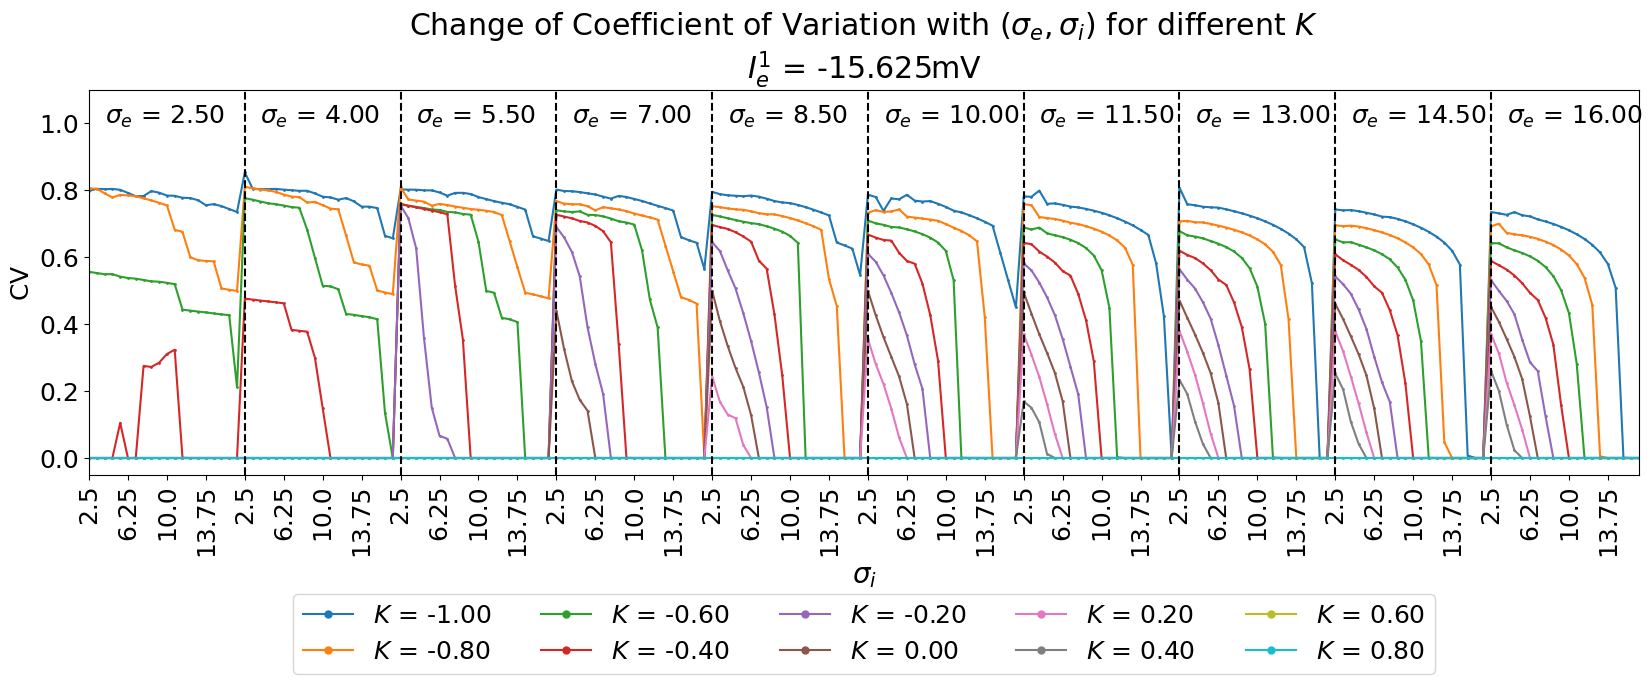

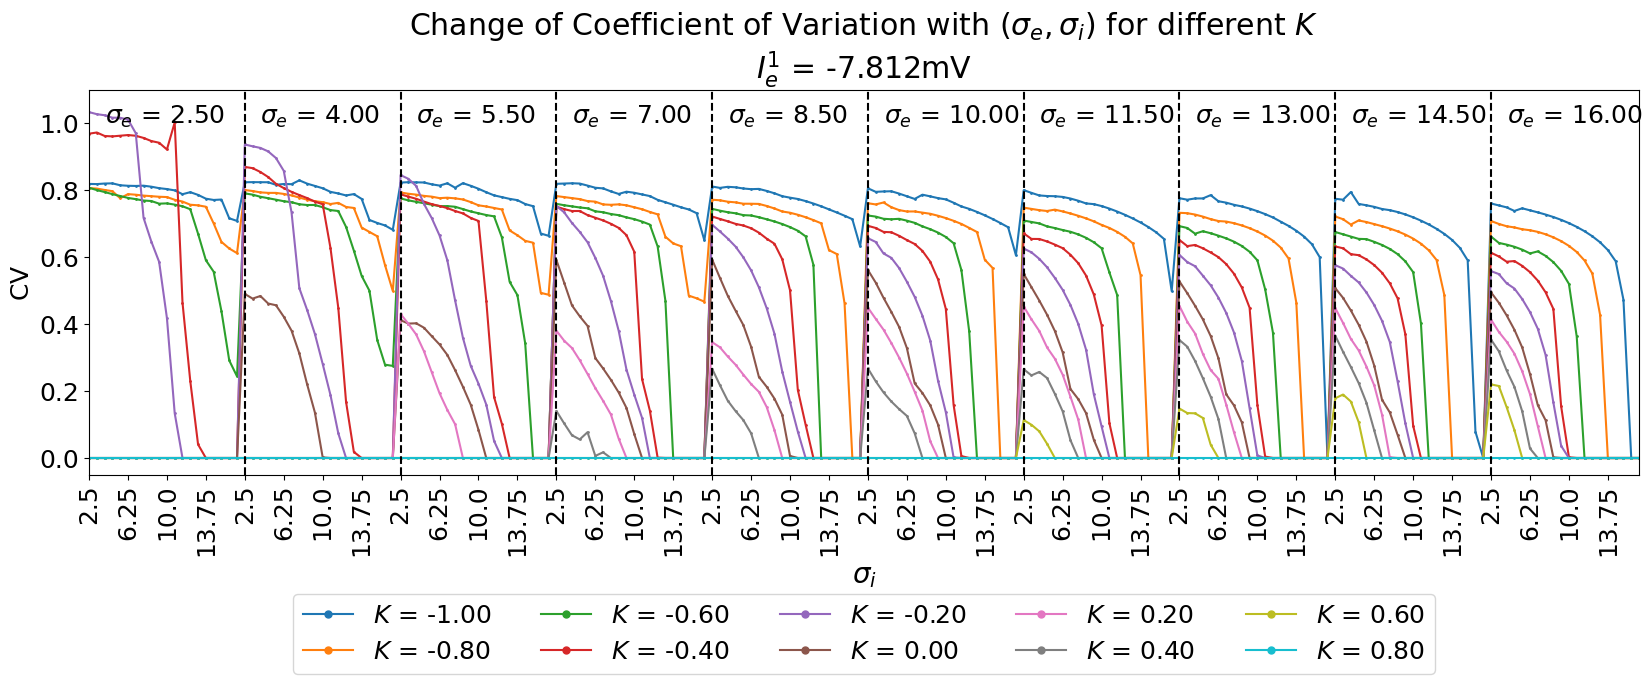

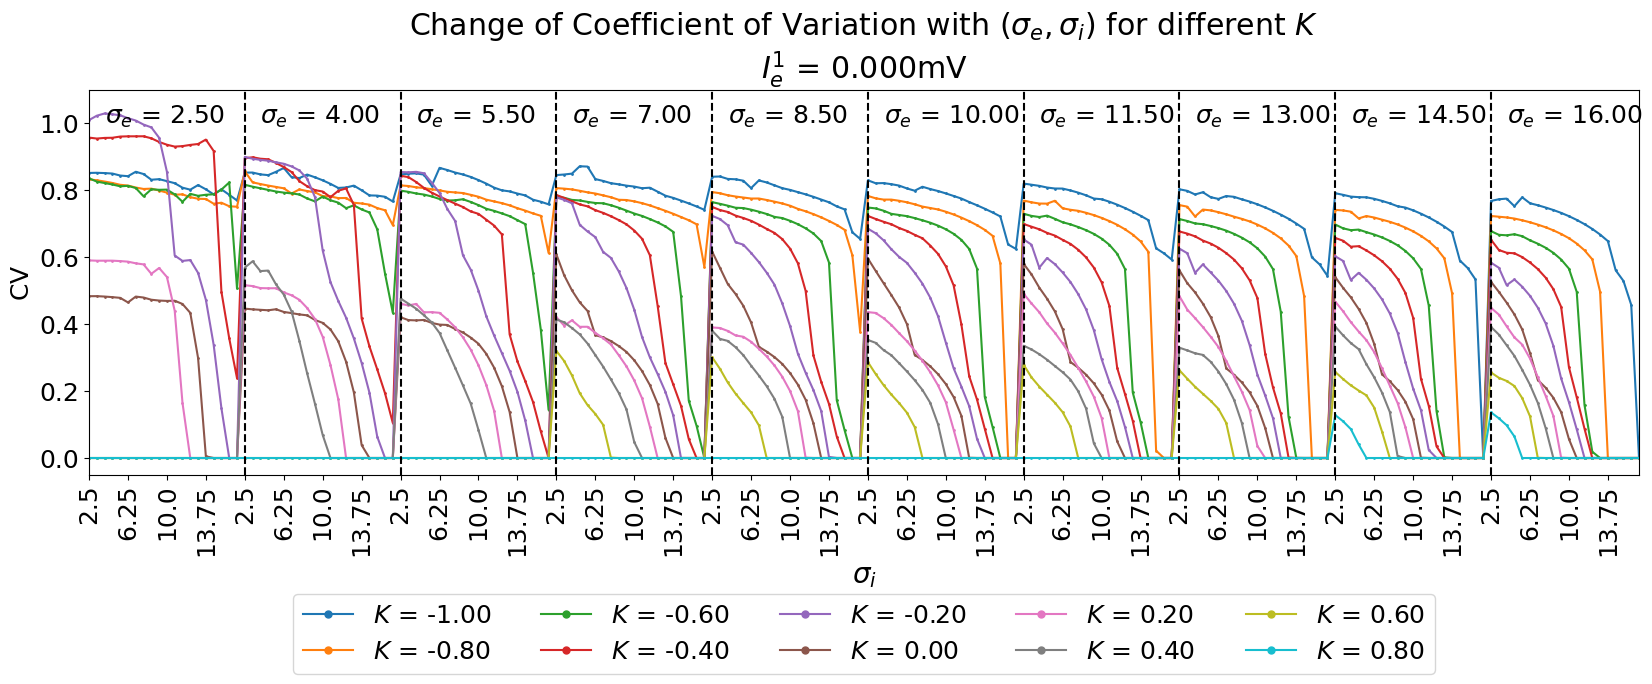

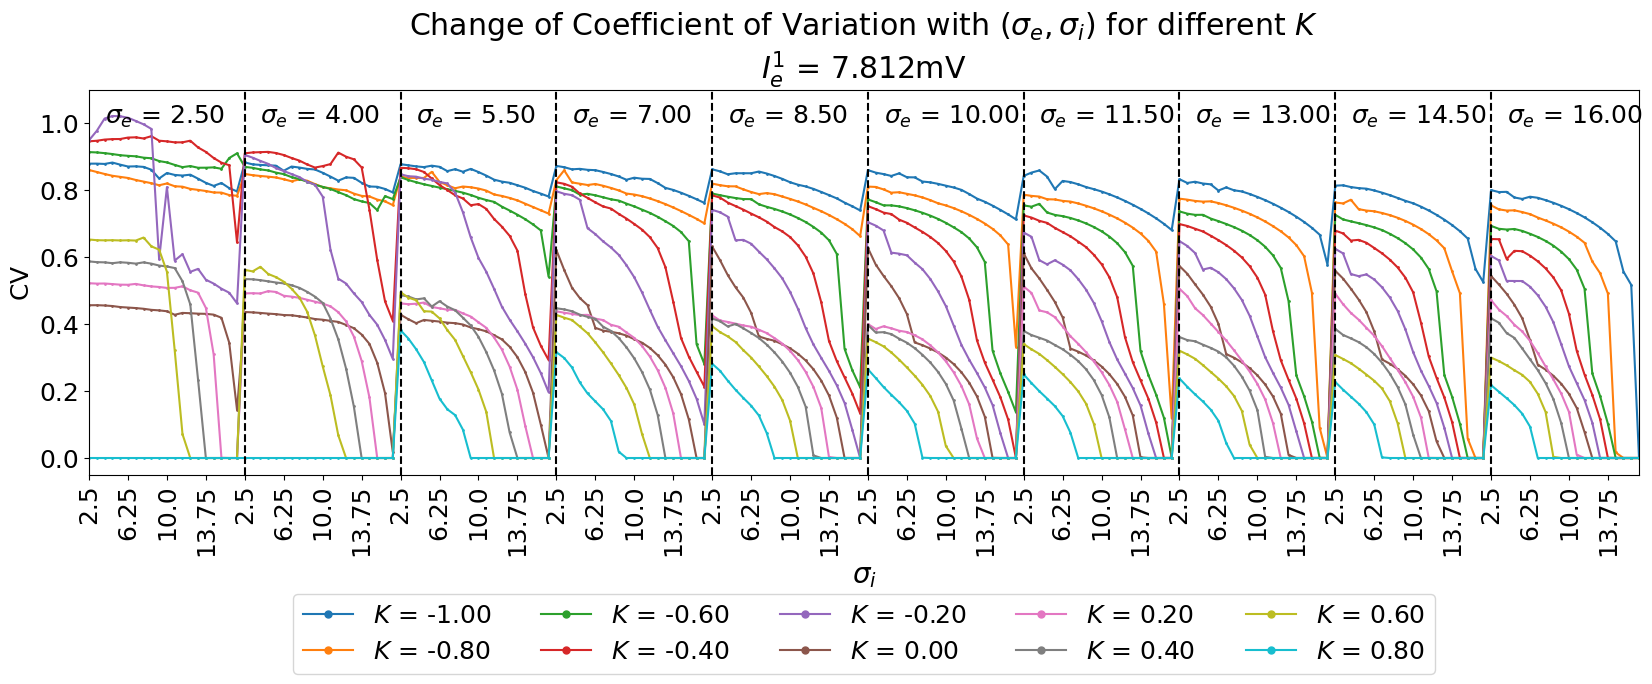

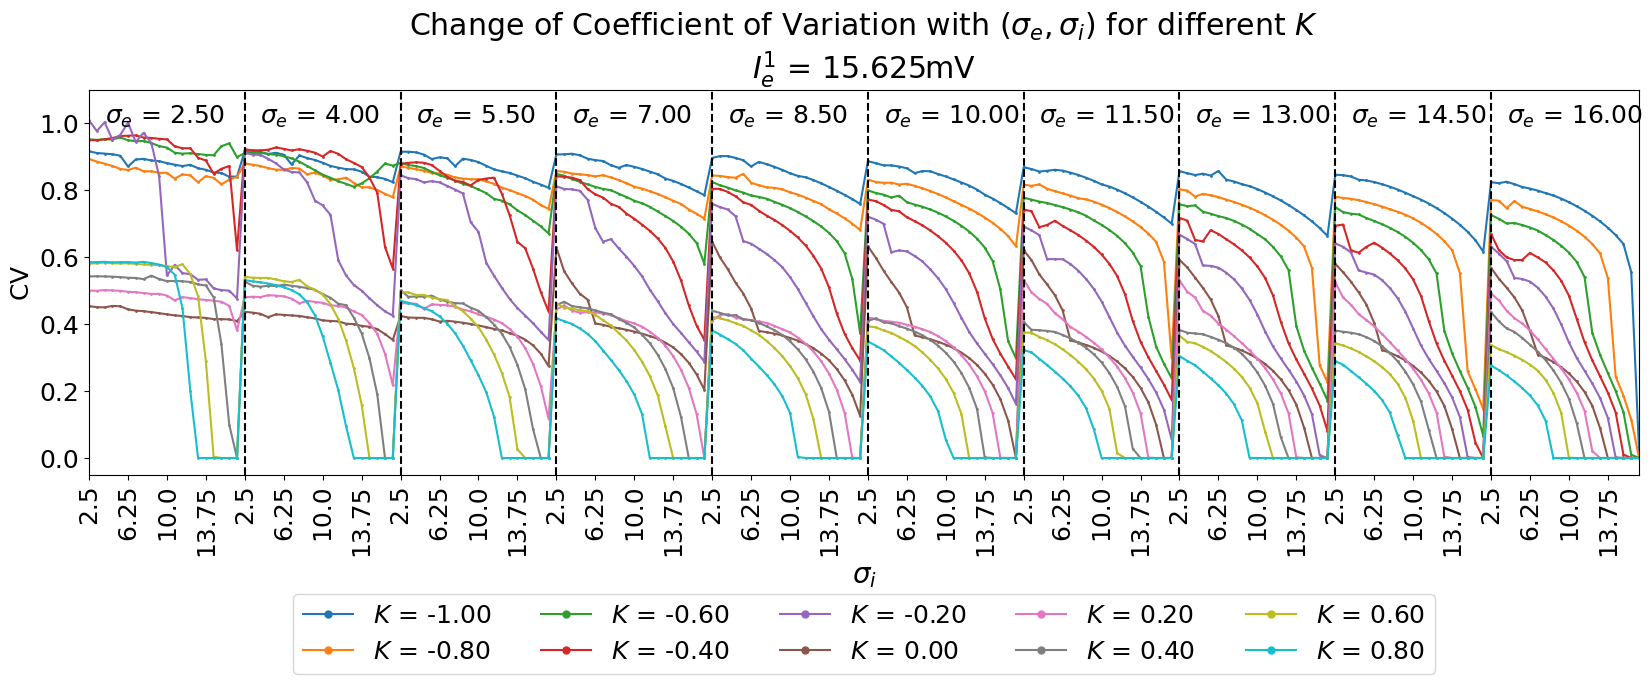

In [23]:
xlabels = np.repeat(eval_sigi[0 : sigi_steps : 5][np.newaxis, ...], 10, axis=0).flatten()

for nf, path in enumerate(file_paths):
    I = iVals[nf]
    with open(path, 'rb') as file_:
        CVarr = abs(pickle.load(file_))

    fileName = f"Scene02_CVMeasures_I_{I:.3f}mV.png"

    plt.figure(figsize=(20, 5))

    for nK in range(k_steps):
        kCvarr = CVarr[nK, :, :]
        plt.plot(abs(kCvarr.flatten()), '-o', markersize=1, label=r"$K$" + f" = {eval_K[nK]:.2f}")

    for x in range(20, len(kCvarr.flatten()), 20):
        plt.axvline(x=x, linestyle='--', color='k')
        plt.text(x = x - 18, y = 1.0, s = r"$\sigma_e$" + f" = {eval_sige[x // 20 - 1]:.2f}")

    plt.text(x = sige_steps * sigi_steps - 18, y = 1.0, s = r"$\sigma_e$" + f" = {eval_sige[-1]:.2f}")

    plt.xlim(0, 199); plt.ylim(-0.05, 1.1)
    plt.xticks(np.arange(0, 200, 5), xlabels, rotation=90)
    plt.xlabel(r"$\sigma_i$", fontsize=20); plt.ylabel(r"$\mathrm{CV}$")
    plt.title(r"Change of Coefficient of Variation with $(\sigma_e, \sigma_i)$ for different $K$" + "\n" + r"$I^{1}_e$ = " + f"{I:.3f}mV")
    plt.legend(loc="lower center", ncols = 5, markerscale=5, bbox_to_anchor=(0.5, -0.55))
    plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')
    plt.show()

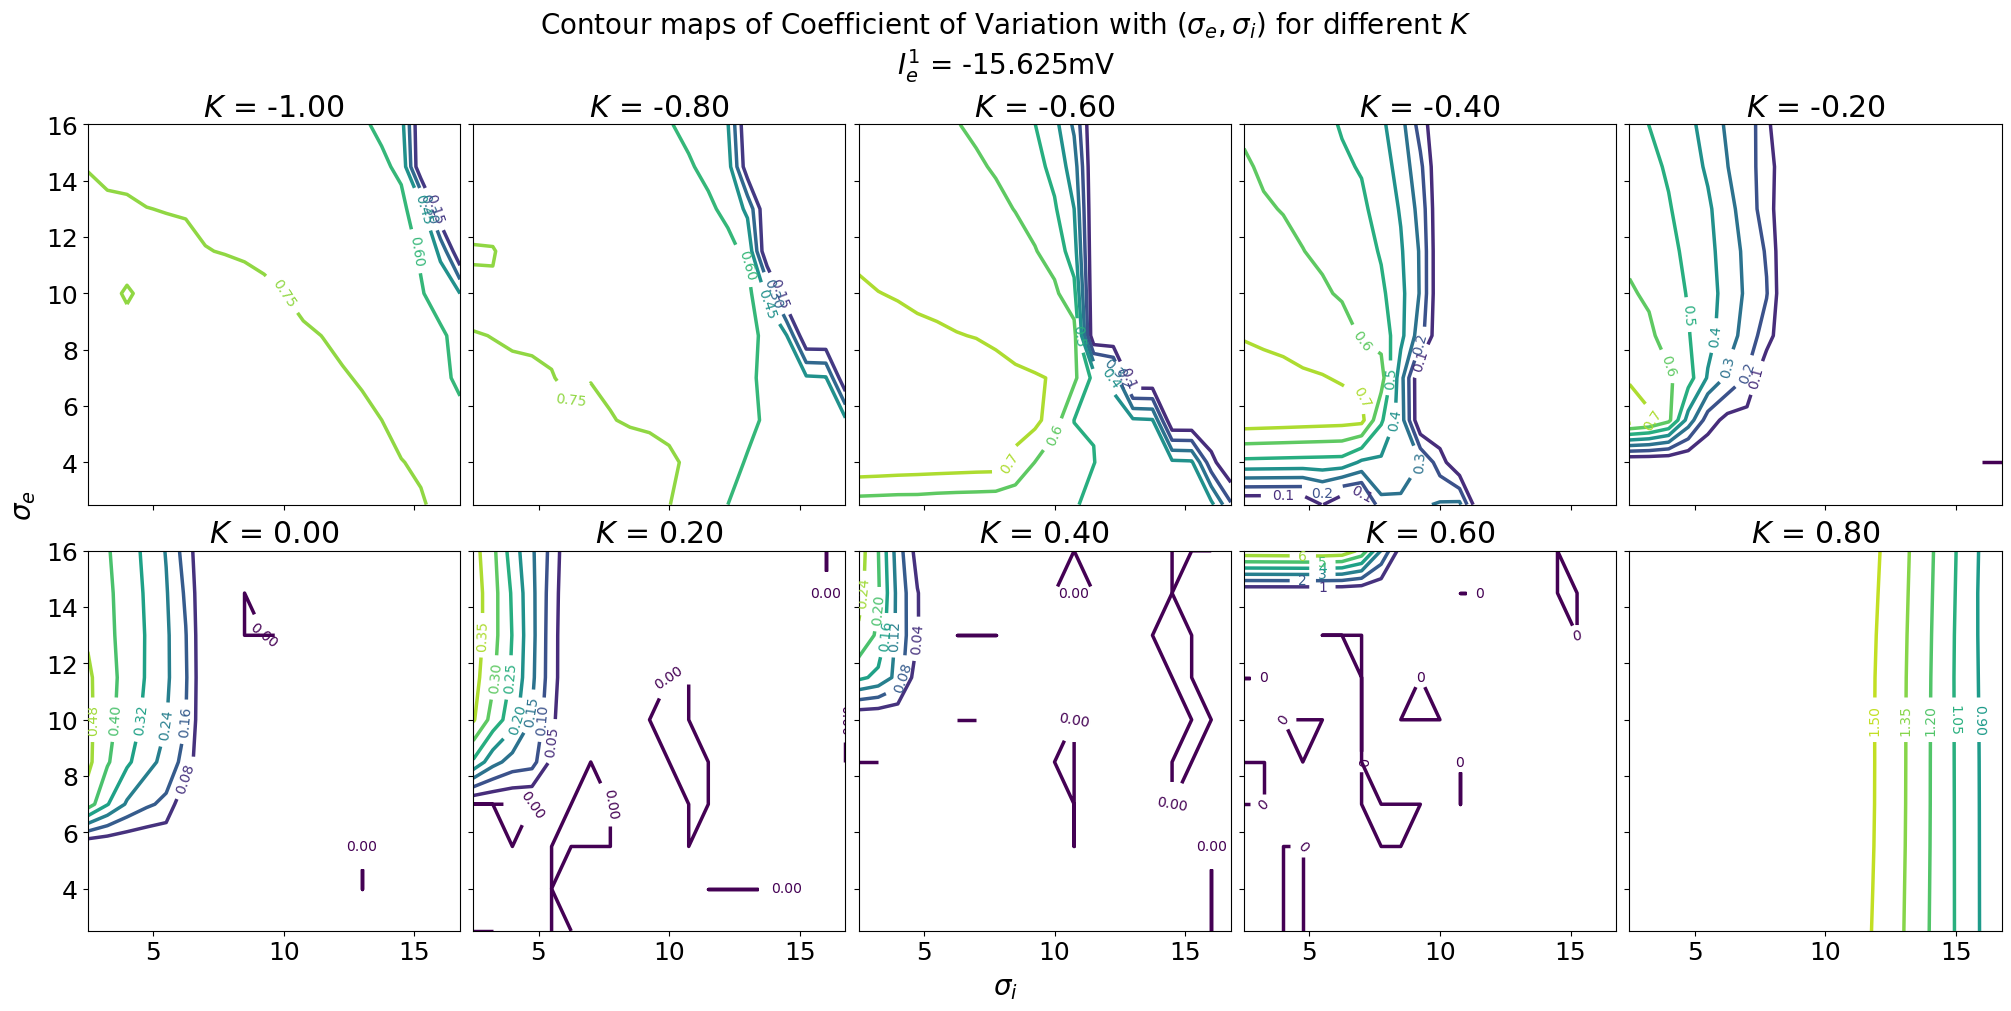

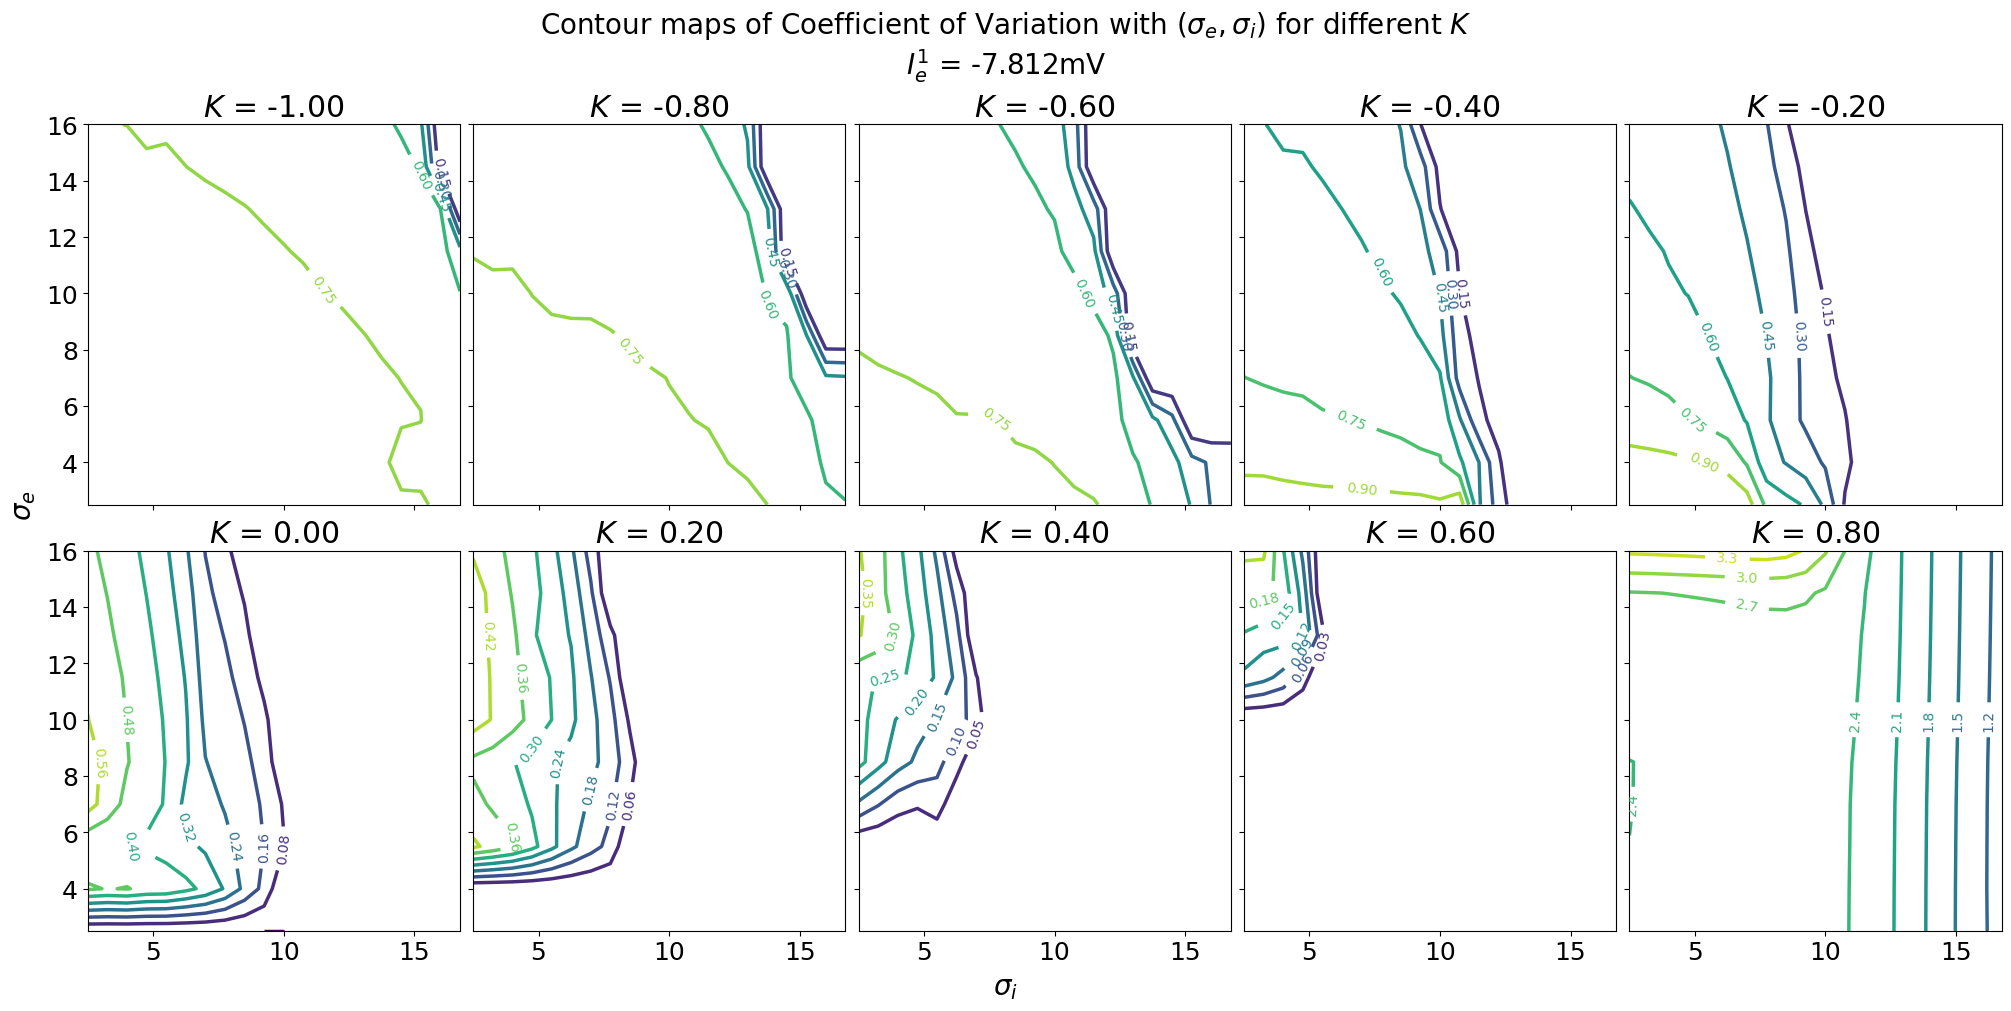

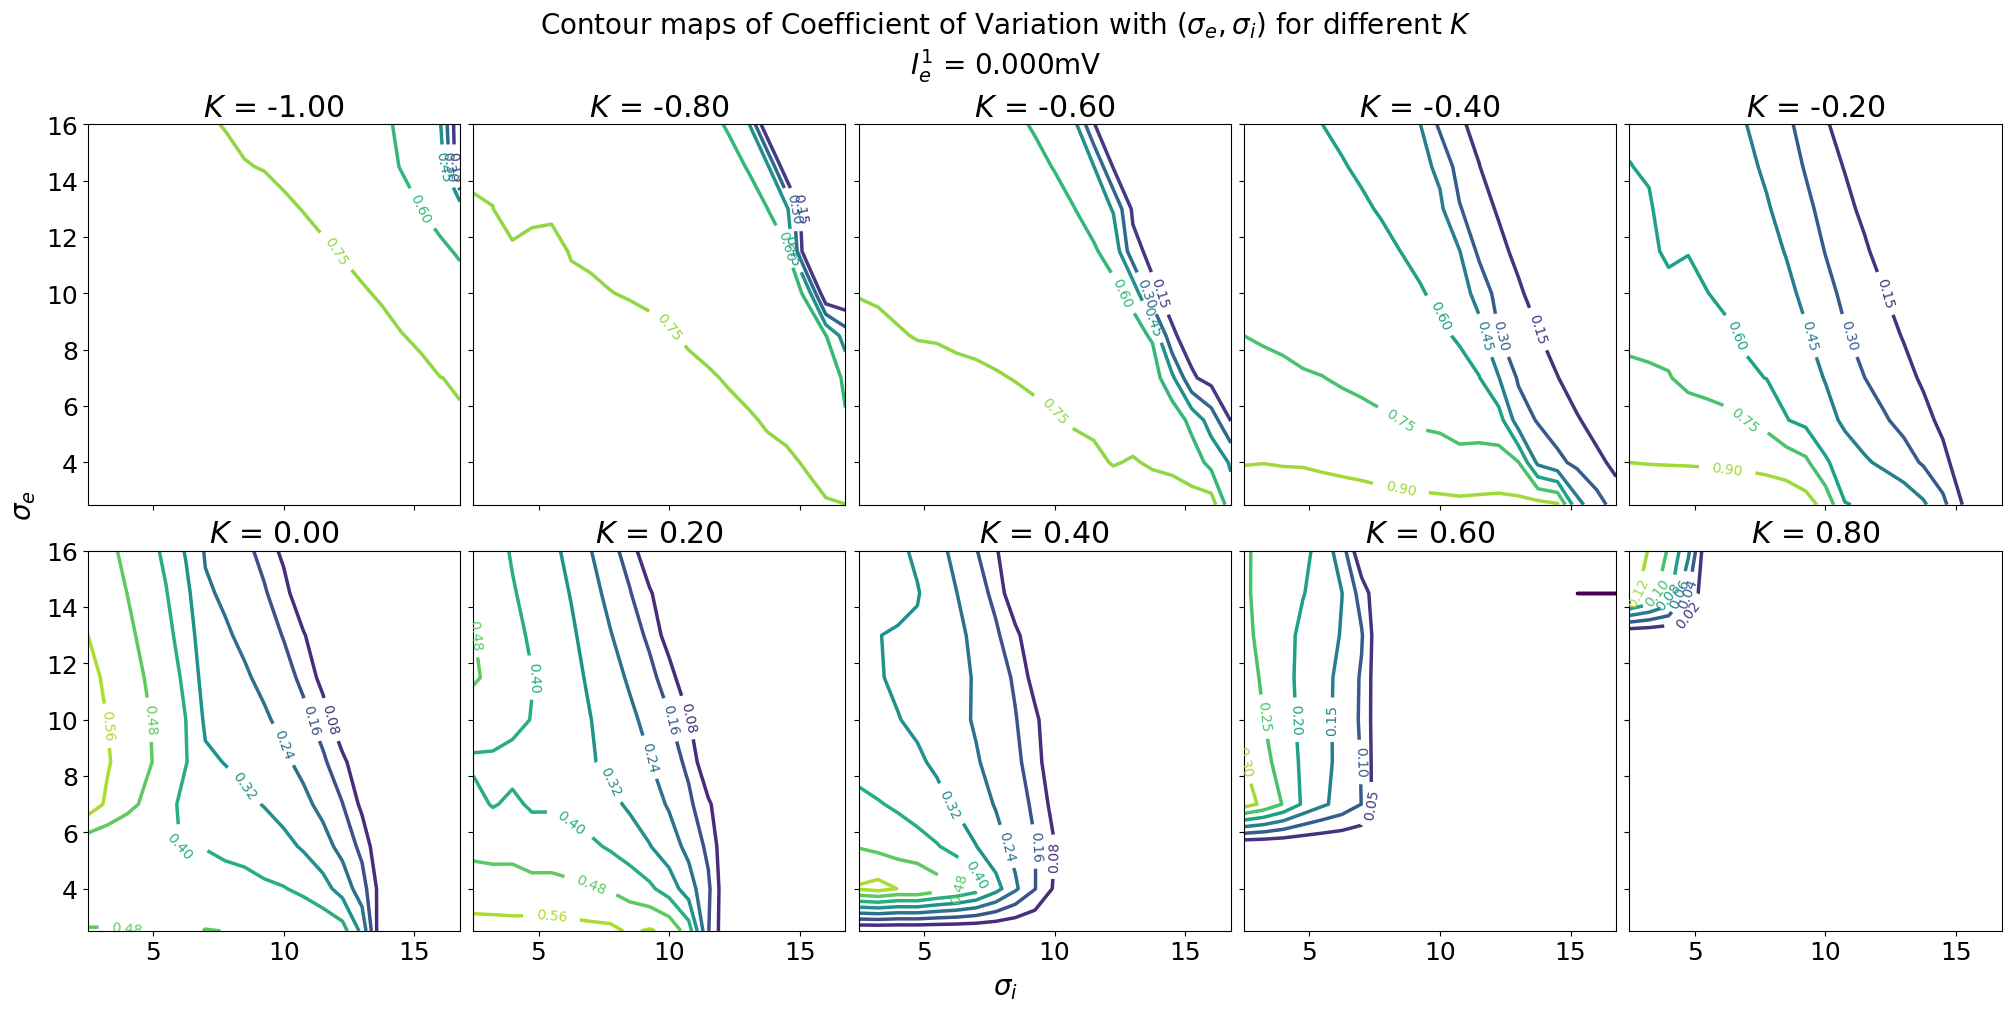

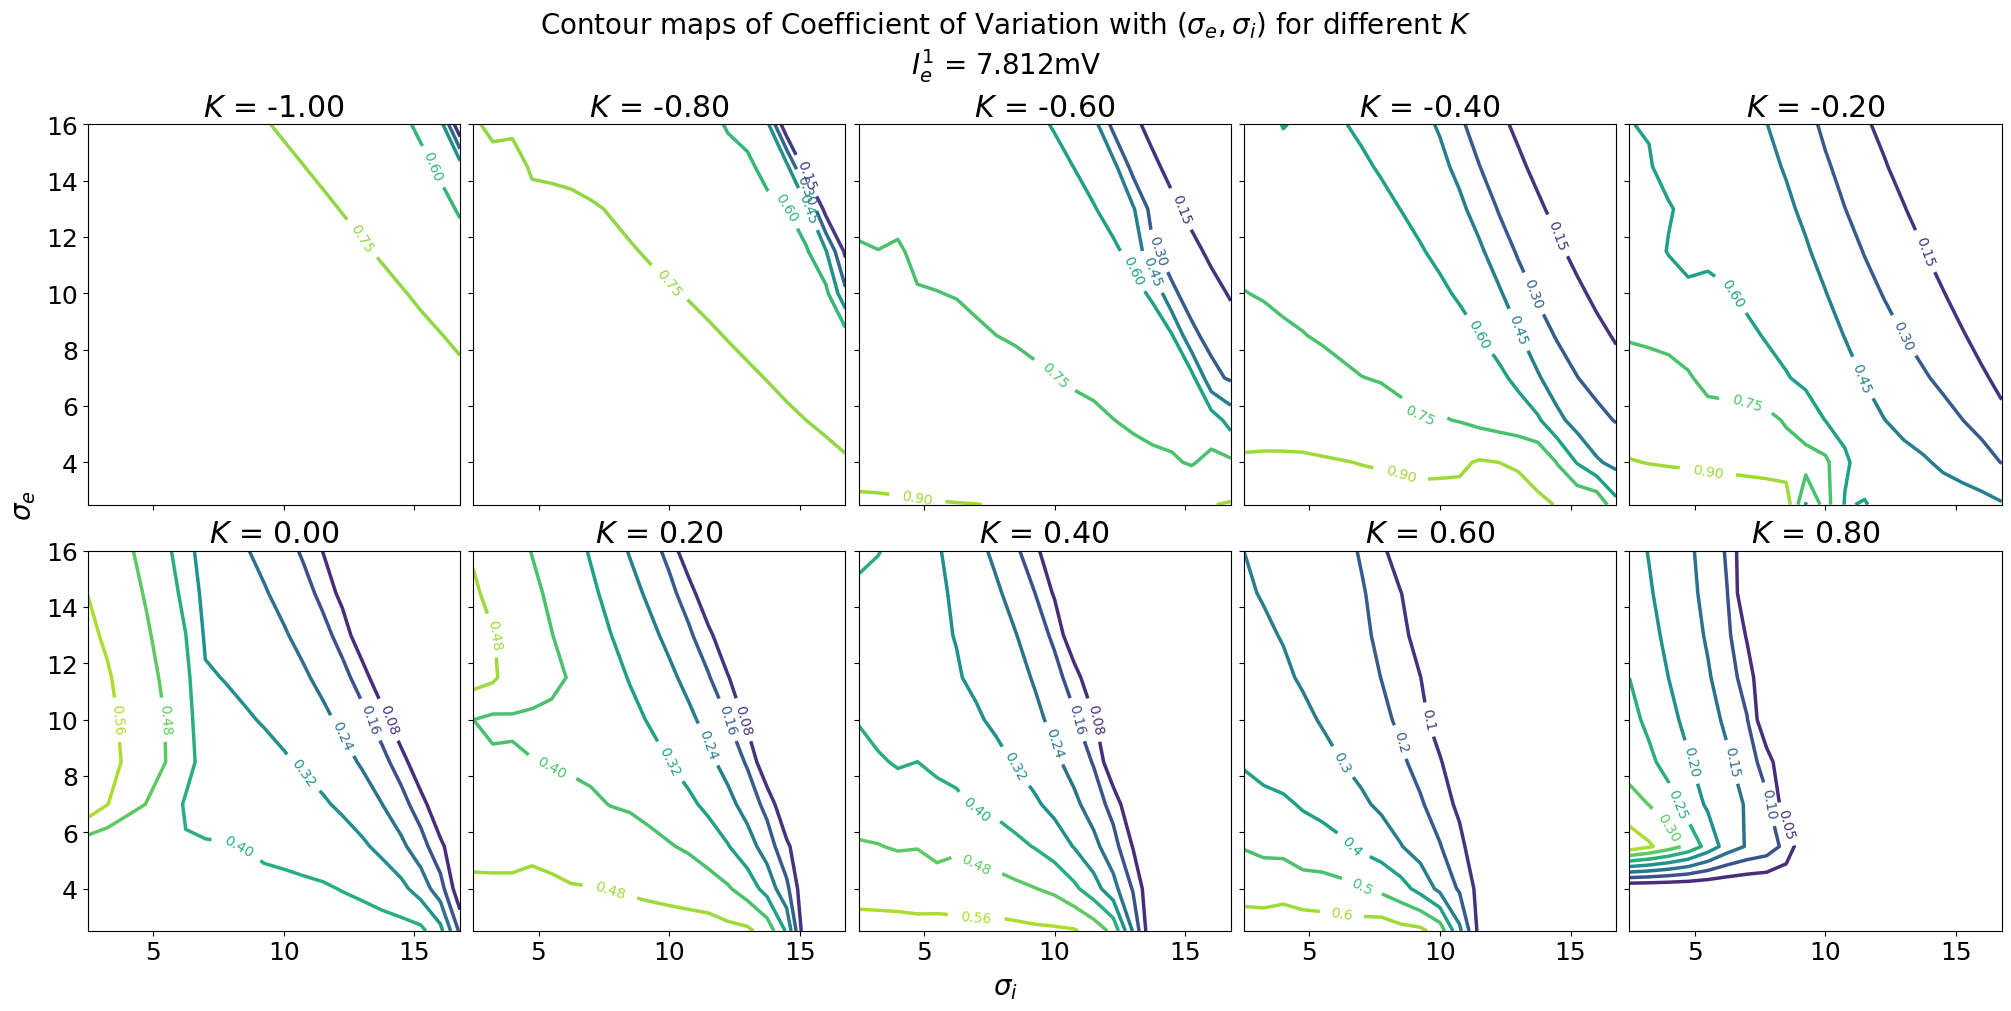

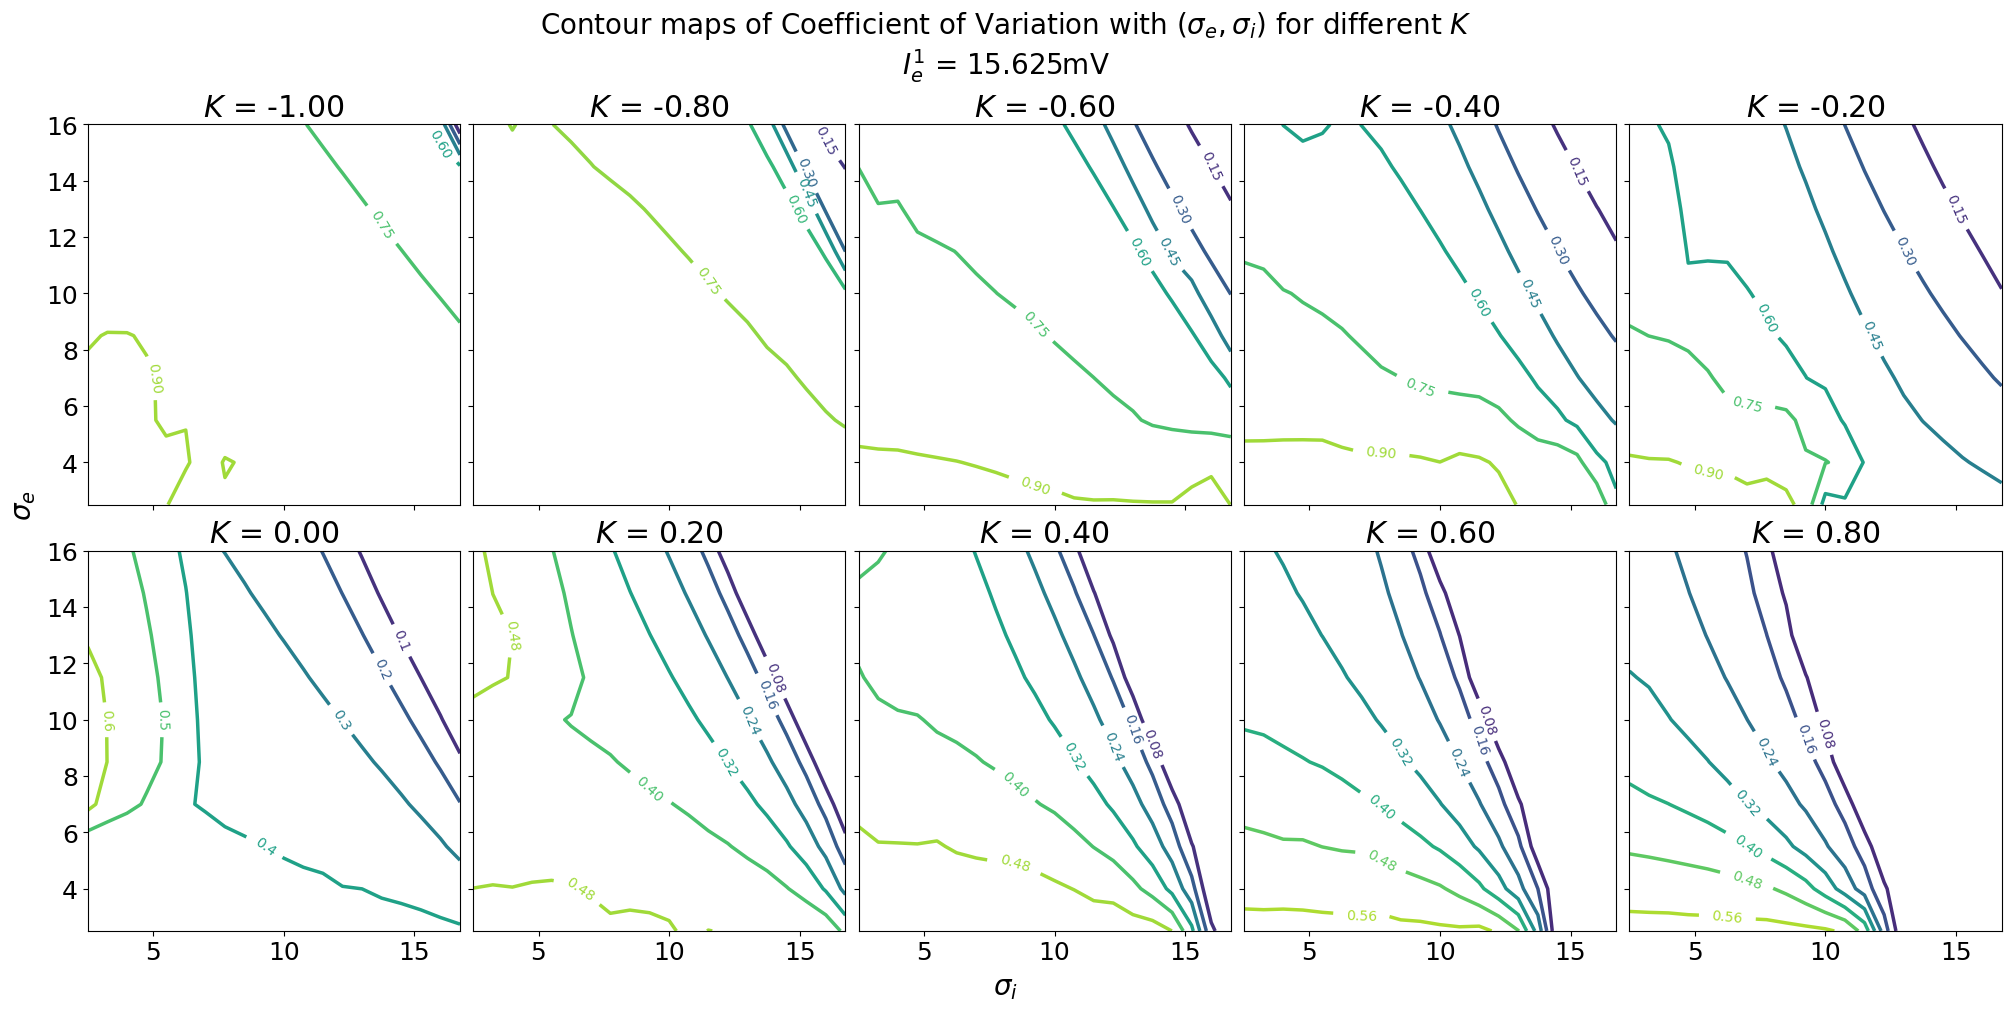

In [8]:
nRows = 2
nCols = 5

for nf, path in enumerate(file_paths):
    I = iVals[nf]
    with open(path, 'rb') as file_:
        CVarr = abs(pickle.load(file_))

    fileName = f"Scene02_CVMeasures_I_{I:.3f}mV_Contours.png"

    fig, ax = plt.subplots(nRows, nCols, figsize=(20, 10), sharex=True, sharey=True, layout='constrained')

    nR = 0

    for nK in range(k_steps):
        if nK >= nCols:
            nR = 1

        CS = ax[nR, nK % nCols].contour(eval_sigi, eval_sige, abs(CVarr[nK, :, :]), vmin=0, linewidths=2.5)
        ax[nR, nK % nCols].clabel(CS, inline=True, fontsize=10)
        ax[nR, nK % nCols].set_title(r"$K$" + f" = {eval_K[nK]:.2f}")

    fig.suptitle(r"Contour maps of Coefficient of Variation with $(\sigma_e, \sigma_i)$ for different $K$" + "\n" + r"$I^{1}_e$ = " + f"{I:.3f}mV", fontsize=20)
    fig.supxlabel(r"$\sigma_i$", fontsize=20)
    fig.supylabel(r"$\sigma_e$", fontsize=20)
    plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')
    plt.show()

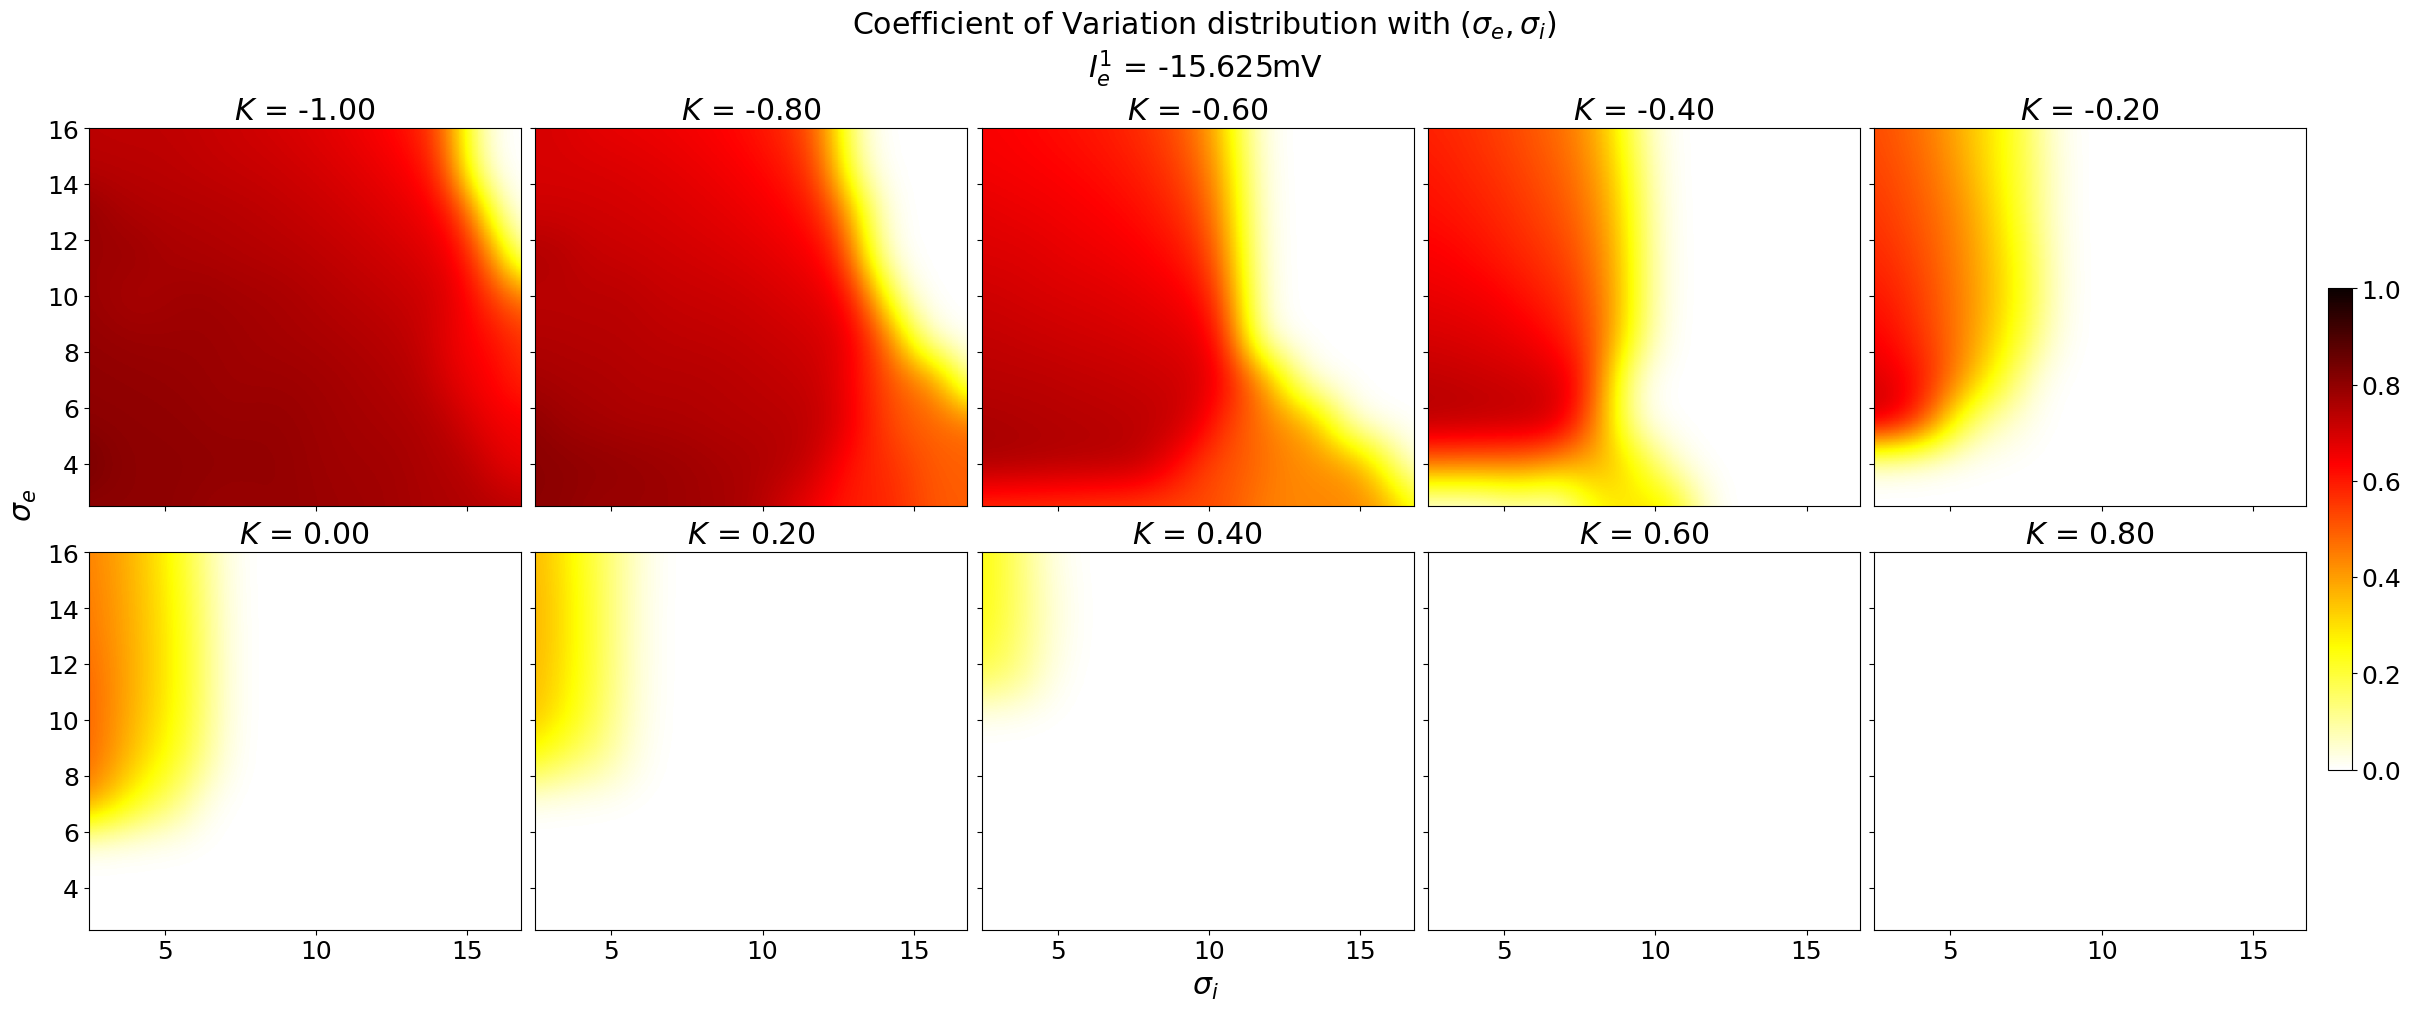

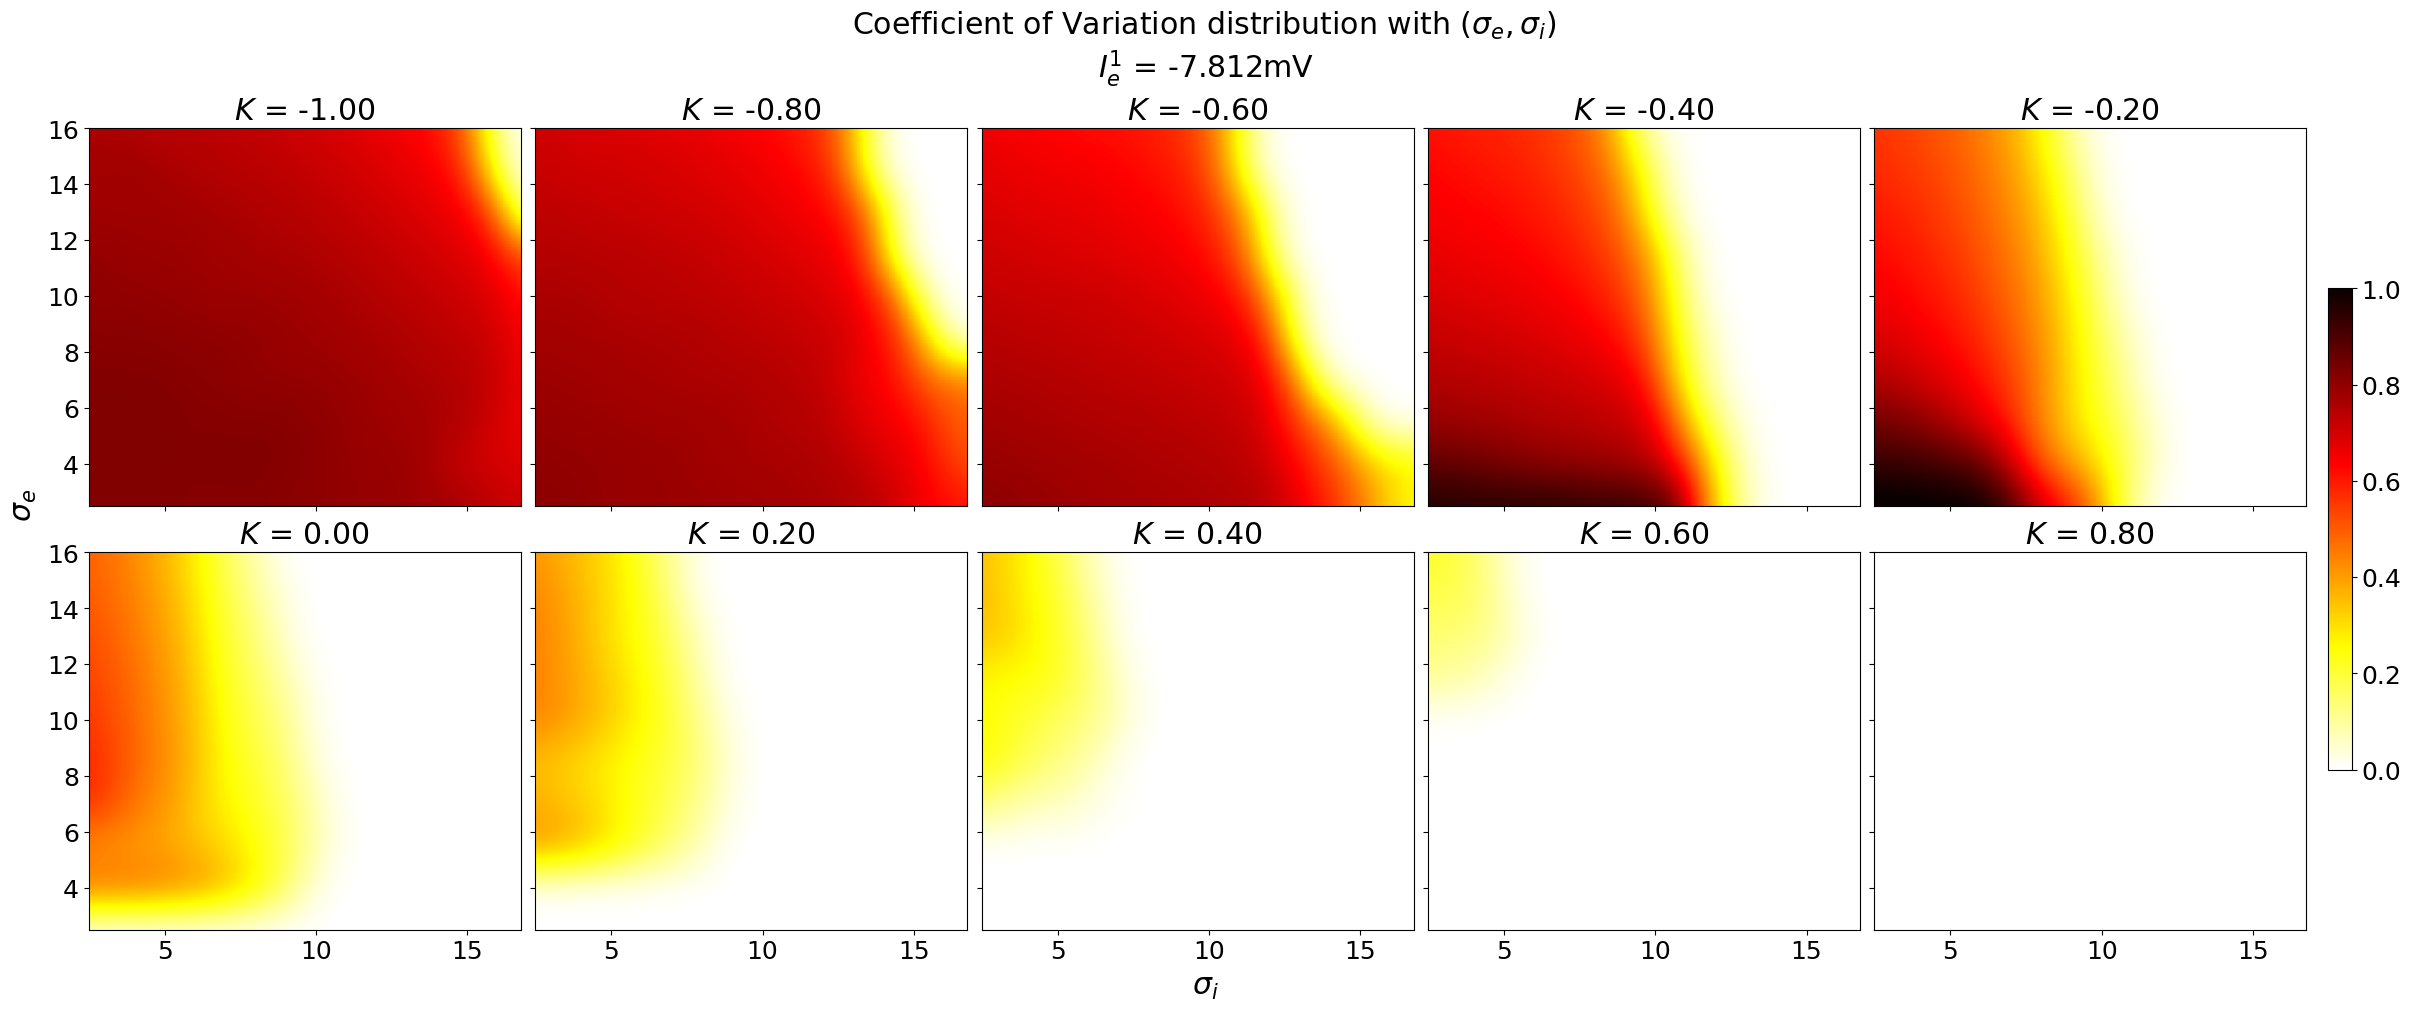

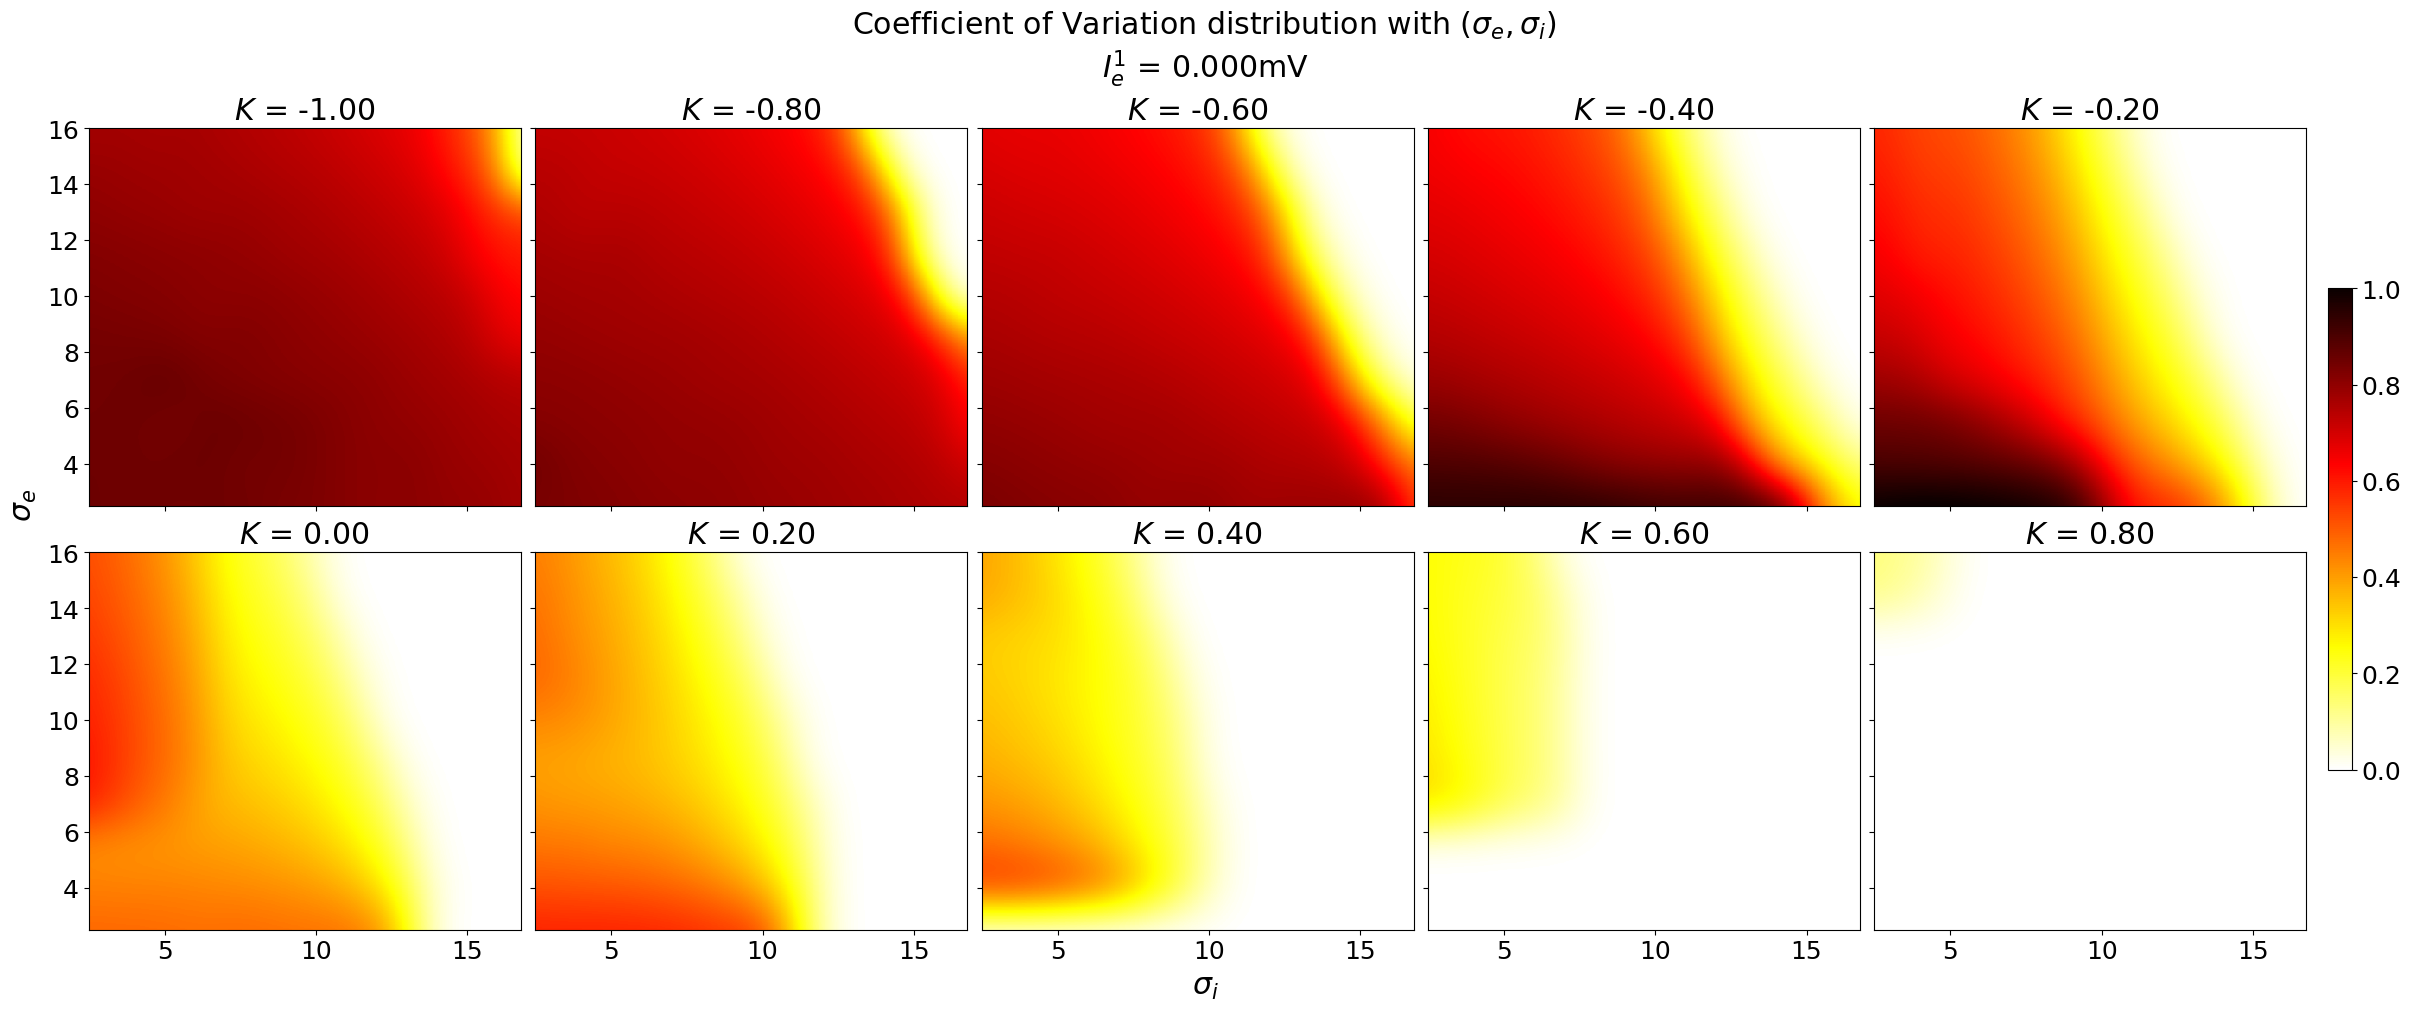

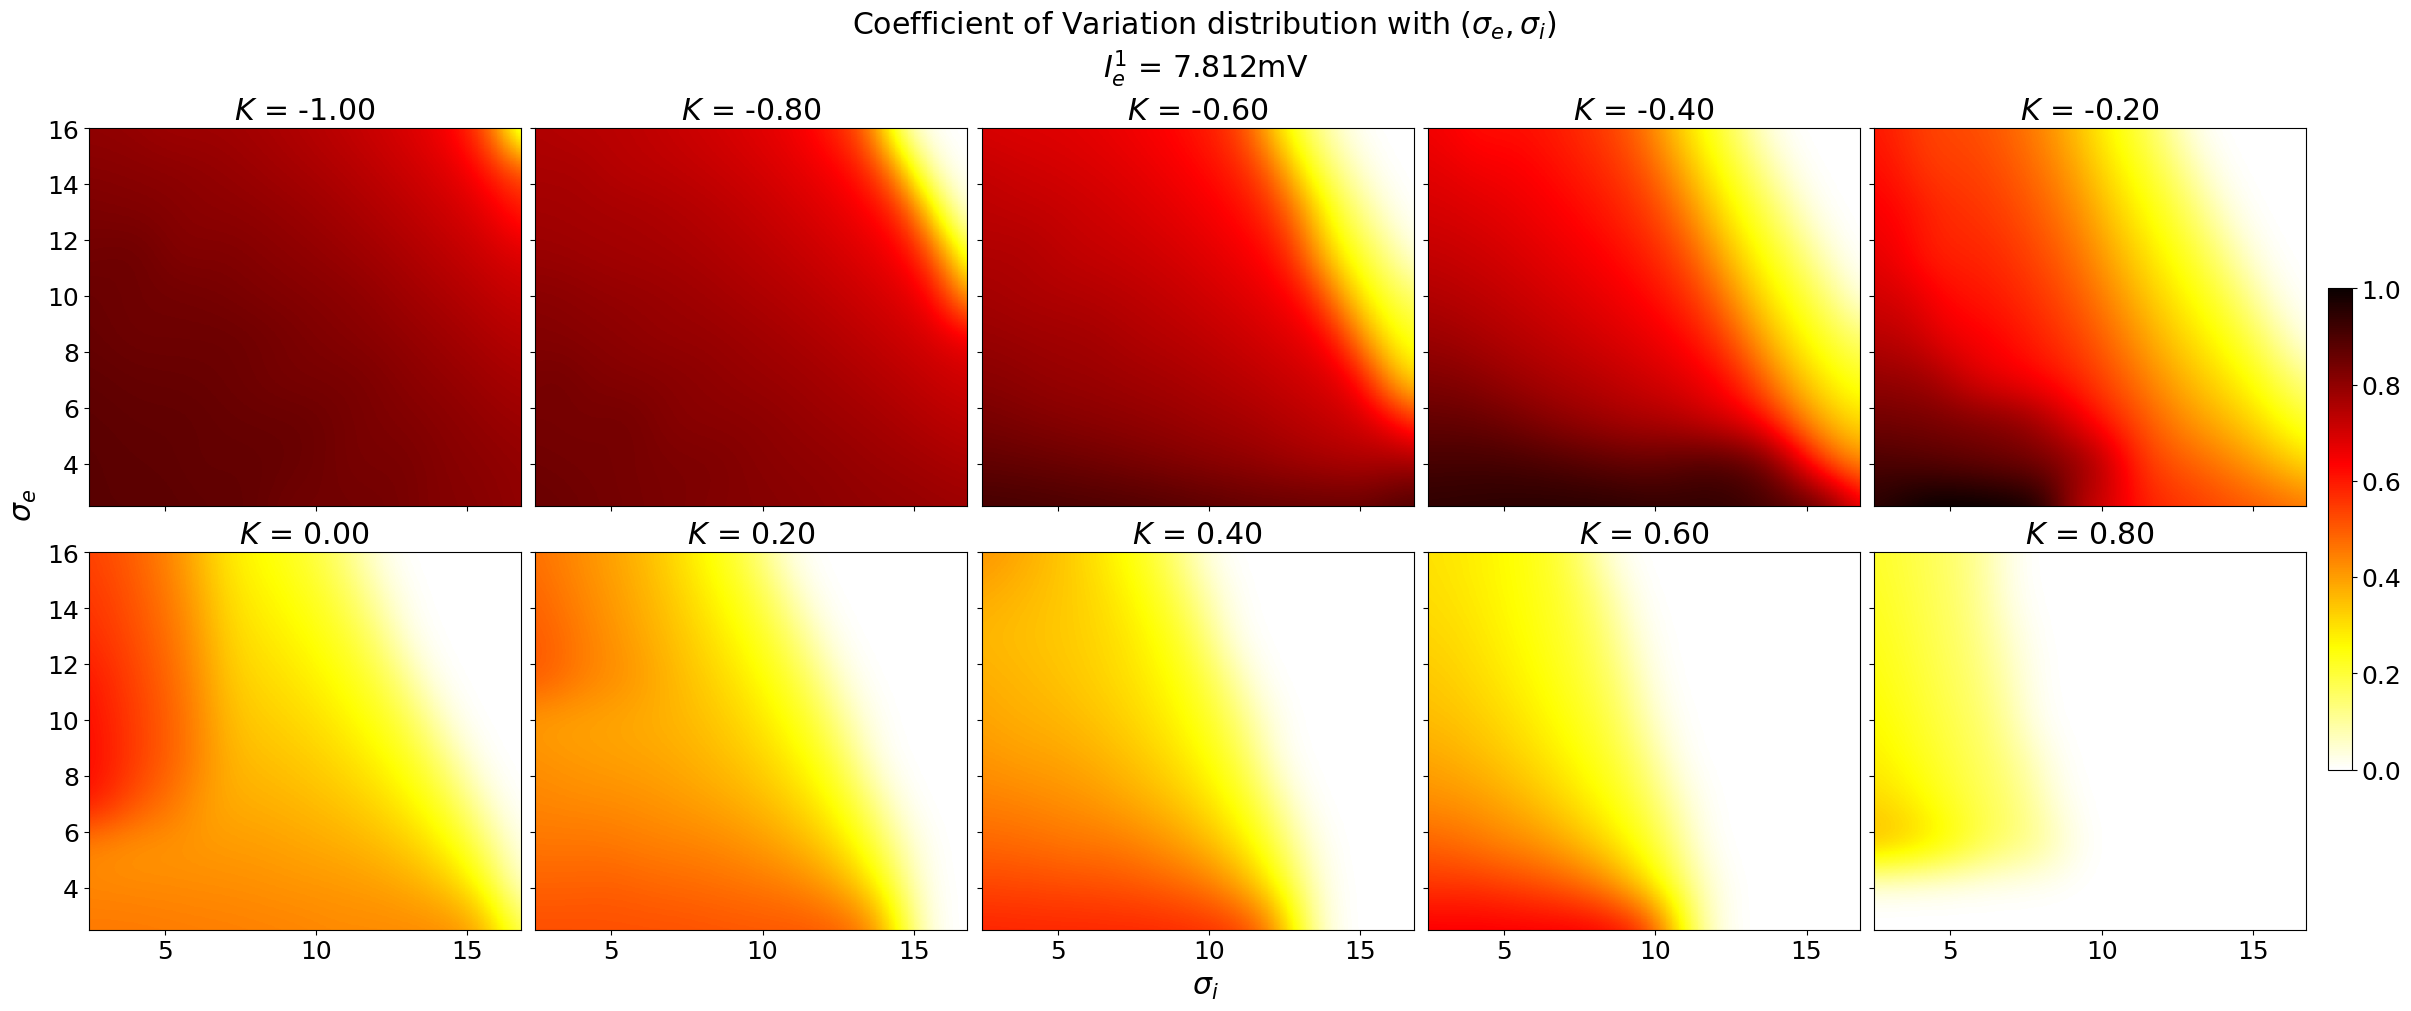

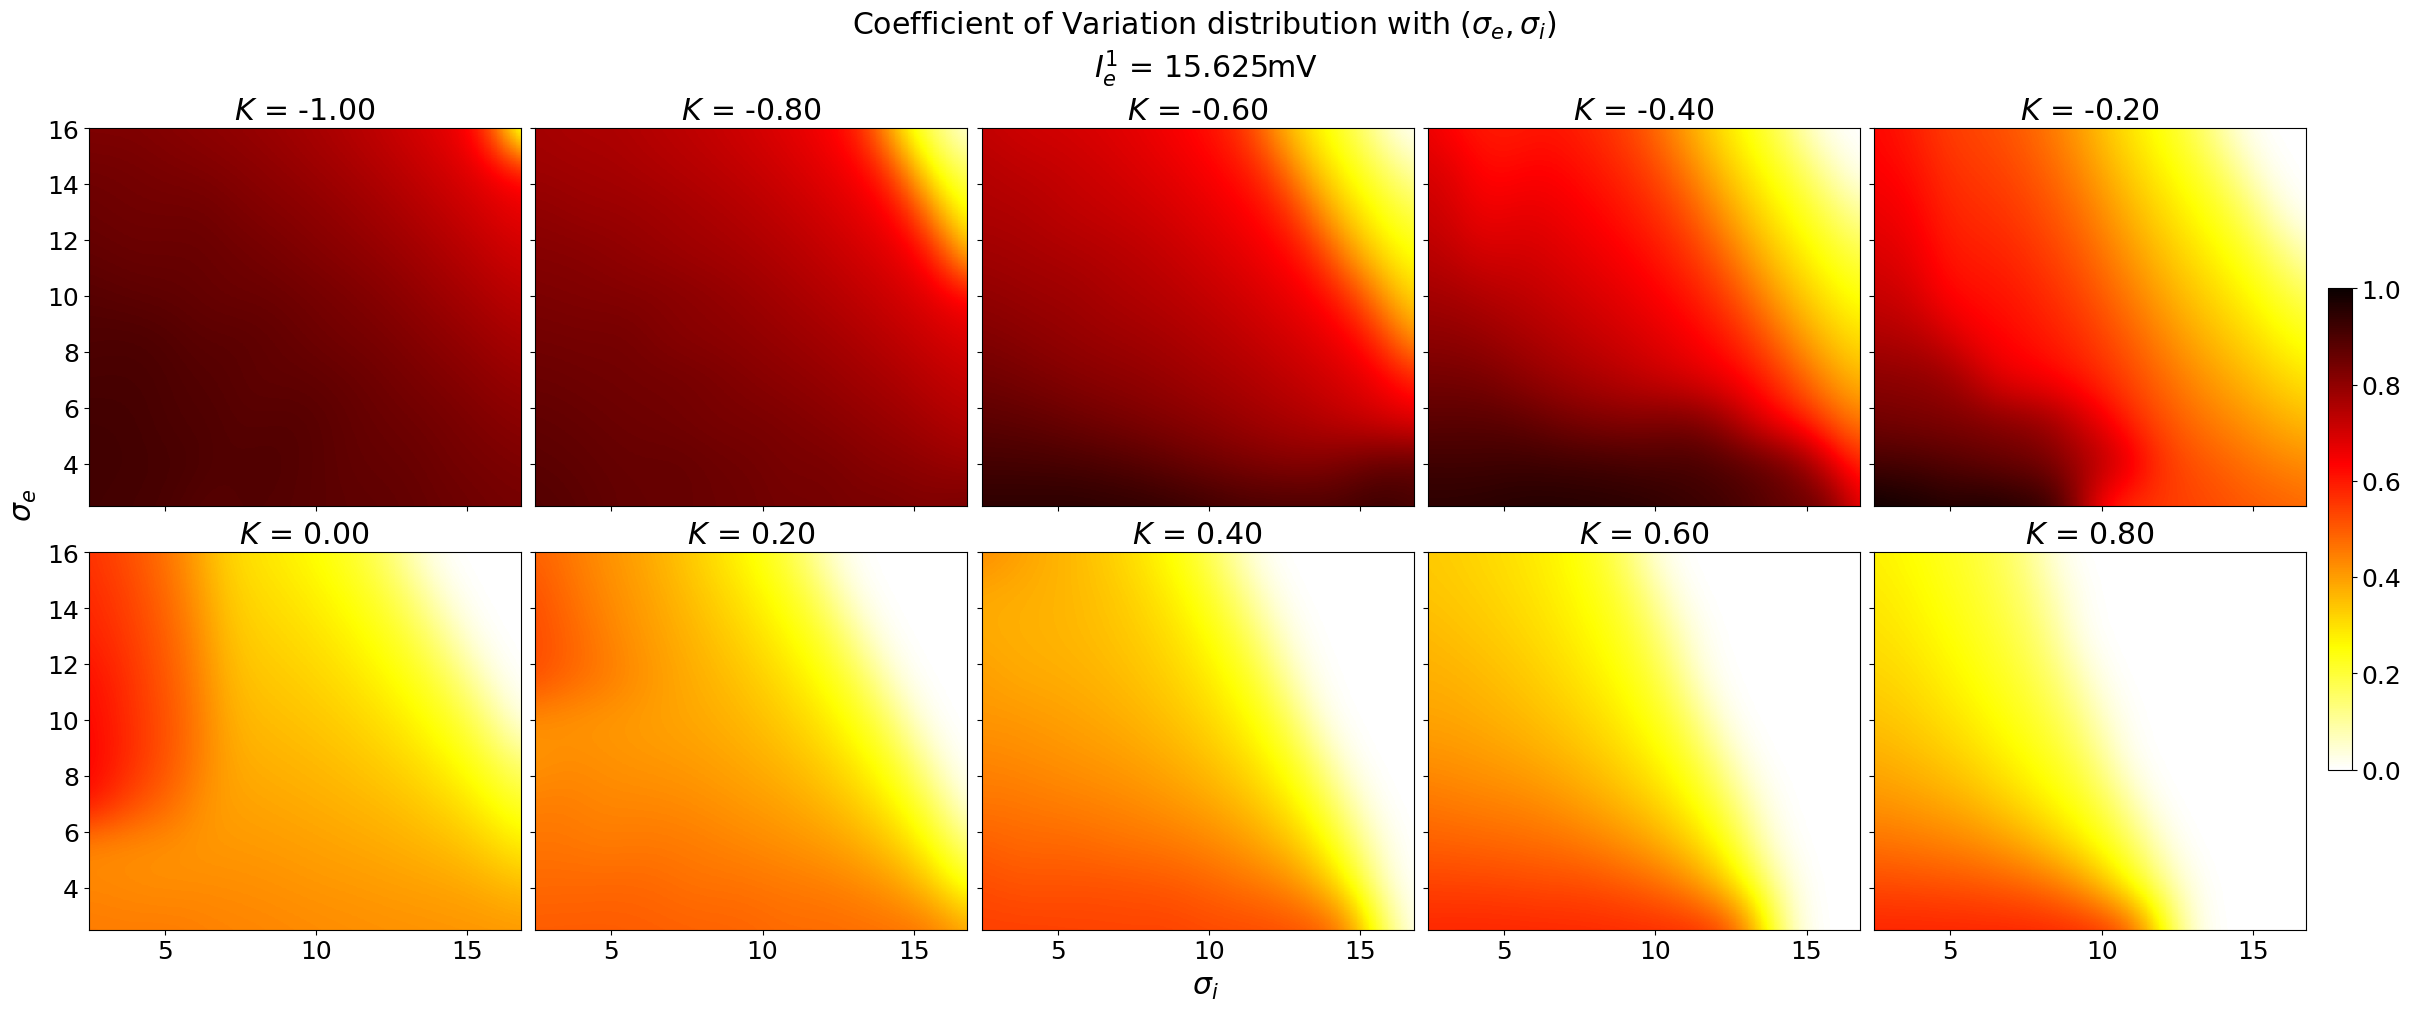

In [24]:
nRows = 2
nCols = 5

for nf, path in enumerate(file_paths):
    I = iVals[nf]
    with open(path, 'rb') as file_:
        CVarr = abs(pickle.load(file_))

    fileName = f"Scene02_CVMeasures_I_{I:.3f}mV_Heatmap.png"

    fig, ax = plt.subplots(nRows, nCols, figsize=(24, 10), sharex=True, sharey=True, layout='constrained')

    nR = 0
    for nK in range(k_steps):
        if nK >= nCols:
            nR = 1

        sige_arr, sigi_arr, response_map = upsampling_smooting(abs(CVarr[nK, :, :]), eval_sigi, eval_sige, 
                                                    y_min = eval_sige[0], y_max = eval_sige[-1], x_min = eval_sigi[0], x_max = eval_sigi[-1], 
                                                    sigma_x = 25, sigma_y = 25,  resolution = 500)
            
        pcm = ax[nR, nK % nCols].pcolormesh(sigi_arr, sige_arr, response_map, cmap='hot_r', vmin=0, vmax=1)
        ax[nR, nK % nCols].set_title(r"$K$" + f" = {eval_K[nK]:.2f}")

        if nR == 1 and nK % nCols == 4:
            fig.colorbar(pcm, ax=ax[:, nK % nCols], shrink=0.6, location='right')

    fig.suptitle(r"Coefficient of Variation distribution with $(\sigma_e, \sigma_i)$ " + "\n" + r"$I^{1}_e$ = " + f"{I:.3f}mV")
    fig.supxlabel(r"$\sigma_i$")
    fig.supylabel(r"$\sigma_e$")
    plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')
    plt.show()

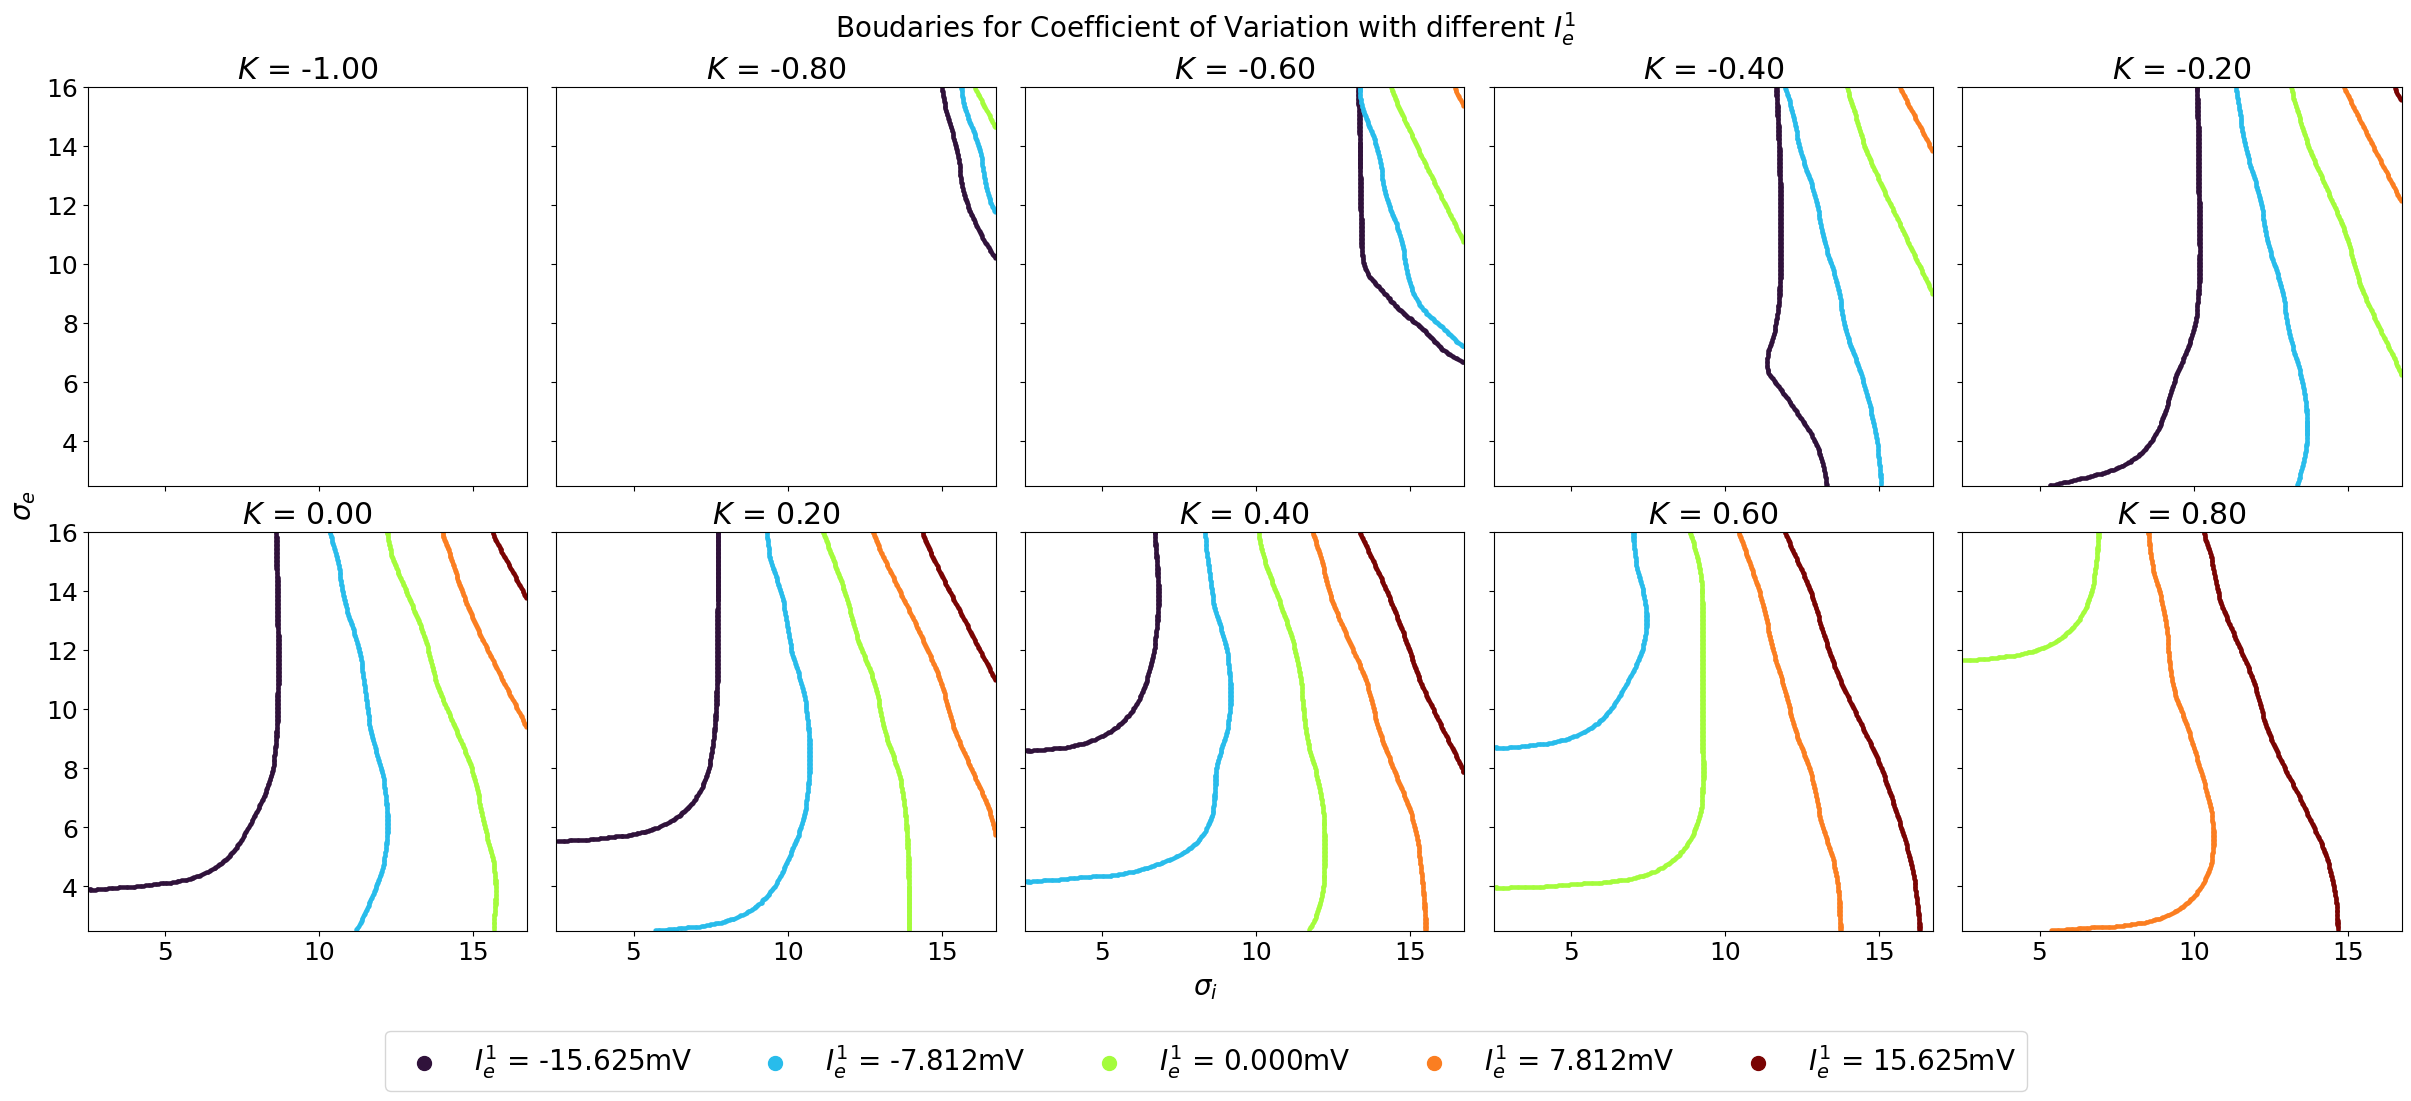

In [10]:
nRows = 2
nCols = 5

colors= plt.get_cmap('turbo')
colorIter = iter(colors(np.linspace(0, 1, len(iVals))))
fig, ax = plt.subplots(nRows, nCols, figsize=(24, 10), sharex=True, sharey=True, layout='constrained')

fileName = f"Scene02_CVMeasures_Boundaries_I.png"

for nf, path in enumerate(file_paths):
    I = iVals[nf]
    color = next(colorIter)
    with open(path, 'rb') as file_:
        CVarr = abs(pickle.load(file_))
    
    nR = 0
    for nK in range(k_steps):
        if nK >= nCols:
            nR = 1
        sige_arr, sigi_arr, response_map = upsampling_smooting(abs(CVarr[nK, :, :]), eval_sigi, eval_sige, 
                                                    y_min = eval_sige[0], y_max = eval_sige[-1], x_min = eval_sigi[0], x_max = eval_sigi[-1], 
                                                    sigma_x = 25, sigma_y = 25,  resolution = 500)
        
        thresh_map = deepcopy(response_map)
        thresh_map = np.round(thresh_map, 3)
        thresh_map[thresh_map > 0.00] = 1
        thresh_map[thresh_map <= 0.00] = 0
        edge_boundary, sigi_edges, sige_edges = boundary_detection(thresh_map, sige_arr, sigi_arr)

        ax[nR, nK % nCols].set_title(r"$K$" + f" = {eval_K[nK]:.2f}")
        ax[nR, nK % nCols].set_xlim(sigi_arr[0], sigi_arr[-1]); plt.ylim(sige_arr[0], sige_arr[-1])

        if edge_boundary == None:
            if nR == 1 and nK % nCols == 4:
                ax[nR, nK % nCols]. scatter(0, 0, s = 16, c = color, marker='.', label = r"$I^{1}_e$" f" = {I:.3f}mV")
            continue

        if nR == 1 and nK % nCols == 4:
            ax[nR, nK % nCols].scatter(sigi_edges, sige_edges, s = 16, c = color, marker='.', label = r"$I^{1}_e$" f" = {I:.3f}mV")
        else:
            ax[nR, nK % nCols].scatter(sigi_edges, sige_edges, s = 16, c = color, marker='.')

fig.suptitle(r"Boudaries for Coefficient of Variation with different $I^{1}_e$", fontsize=20)
fig.supxlabel(r"$\sigma_i$", fontsize=20)
fig.supylabel(r"$\sigma_e$", fontsize=20)
fig.legend(loc="lower center", markerscale=5, ncols = 5, bbox_to_anchor=(0.5, -0.1), fontsize=20)
plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')
plt.show()

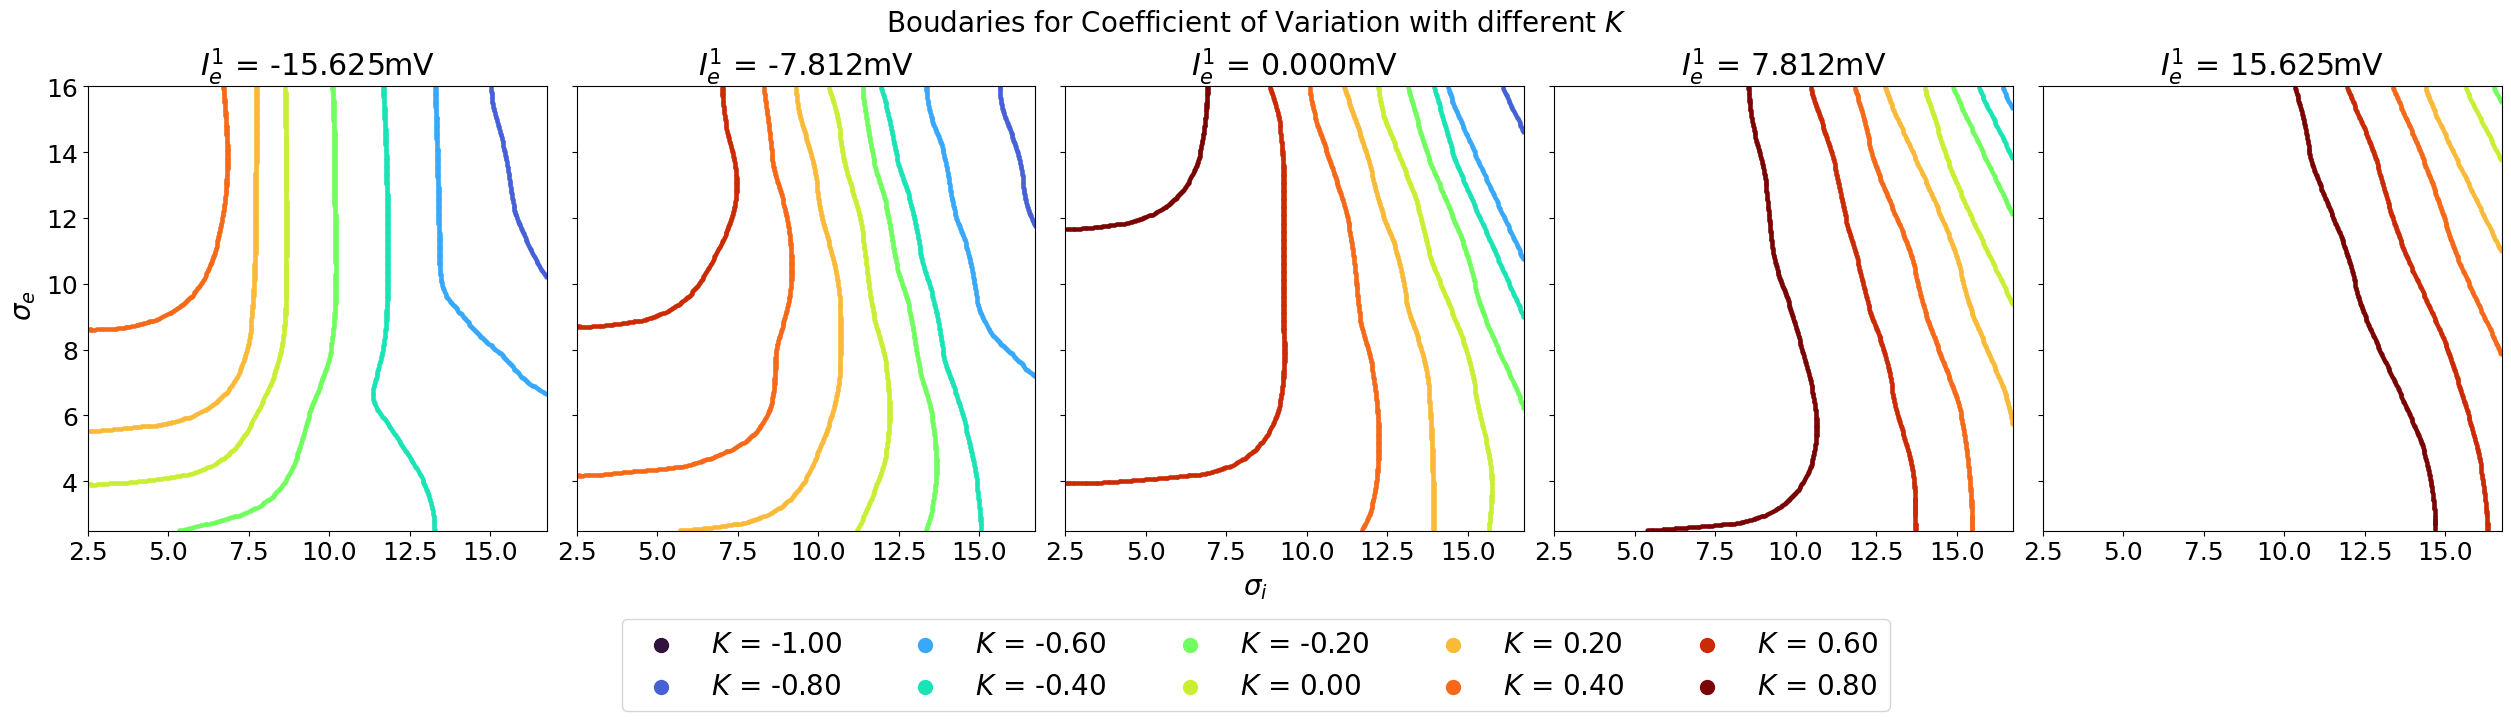

In [21]:
nRows = 1
nCols = 5

fig, ax = plt.subplots(nRows, nCols, figsize=(25, 6), sharex=True, sharey=True, layout='constrained')

fileName = f"Scene02_CVMeasures_Boundaries_K.png"

for nf, path in enumerate(file_paths):
    I = iVals[nf]

    colors= plt.get_cmap('turbo')
    colorIter = iter(colors(np.linspace(0, 1, k_steps)))
    with open(path, 'rb') as file_:
        CVarr = abs(pickle.load(file_))
    
    for nK in range(k_steps):
        color = next(colorIter)
        sige_arr, sigi_arr, response_map = upsampling_smooting(abs(CVarr[nK, :, :]), eval_sigi, eval_sige, 
                                                    y_min = eval_sige[0], y_max = eval_sige[-1], x_min = eval_sigi[0], x_max = eval_sigi[-1], 
                                                    sigma_x = 25, sigma_y = 25,  resolution = 500)
        
        thresh_map = deepcopy(response_map)
        thresh_map = np.round(thresh_map, 3)
        thresh_map[thresh_map > 0.00] = 1
        thresh_map[thresh_map <= 0.00] = 0
        edge_boundary, sigi_edges, sige_edges = boundary_detection(thresh_map, sige_arr, sigi_arr)

        ax[nf % len(iVals)].set_title(r"$I^1_e$" + f" = {I:.3f}mV")
        ax[nf % len(iVals)].set_xlim(sigi_arr[0], sigi_arr[-1]); plt.ylim(sige_arr[0], sige_arr[-1])

        if edge_boundary == None:
            if  nf % len(iVals) == 4:
                ax[nf % len(iVals)]. scatter(0, 0, s = 16, c = color, marker='.', label = r"$K$" f" = {eval_K[nK]:.2f}")
            continue

        if nf % len(iVals) == 4:
            ax[nf % len(iVals)].scatter(sigi_edges, sige_edges, s = 16, c = color, marker='.', label = r"$K$" f" = {eval_K[nK]:.2f}")
        else:
            ax[nf % len(iVals)].scatter(sigi_edges, sige_edges, s = 16, c = color, marker='.')

fig.suptitle(r"Boudaries for Coefficient of Variation with different $K$", fontsize=20)
fig.supxlabel(r"$\sigma_i$", fontsize=20)
fig.supylabel(r"$\sigma_e$", fontsize=20)
fig.legend(loc="lower center", markerscale=5, ncols = 5, bbox_to_anchor=(0.5, -0.2), fontsize=20)
plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')
plt.show()

In [12]:
with open(file_paths[0], 'rb') as file_:
    CVarr = abs(pickle.load(file_))

In [13]:
sige_arr, sigi_arr, response_map = upsampling_smooting(abs(CVarr[-1, :, :]), eval_sigi, eval_sige, 
                                                    y_min = eval_sige[0], y_max = eval_sige[-1], x_min = eval_sigi[0], x_max = eval_sigi[-1], 
                                                    sigma_x = 25, sigma_y = 25,  resolution = 500)
        
thresh_map = deepcopy(response_map)
thresh_map = np.round(thresh_map, 3)
thresh_map[thresh_map > 0.00] = 10
thresh_map[thresh_map <= 0.00] = 0

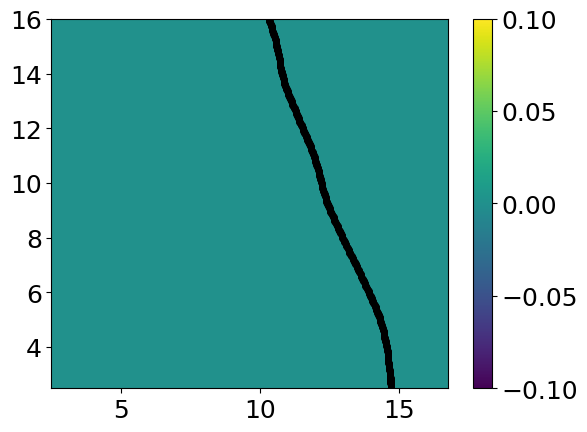

In [14]:
plt.pcolormesh(sigi_arr, sige_arr, thresh_map)
plt.colorbar()
plt.scatter(sigi_edges, sige_edges, s=16, color='k')

In [15]:
edge_boundary, sigi_edges, sige_edges = boundary_detection(thresh_map, sige_arr, sigi_arr)

In [16]:
plot_x = np.linspace(min(sigi_arr), max(sigi_arr), 1000)
plot_y = edge_boundary(plot_x)

TypeError: 'NoneType' object is not callable